# Part 2 Submission for Kevin Rivero and Stef van Gestel
### Our Process
FIXME We completed both a custom model and a PyPSA model of Part 1 to get a full picture.
### Design of this Notebook
Below we have four sections of code:
 1. Code provided by the instructor with minimal edits to pull in our group information
2. Code for a representative scenario run through our PyPSA model.
3. FIXME Code for a representative scenario run through our custom model.
4. Analysis and comparison of KPIs across scenarios for Part 1

Please note that the model examples were included to provide insight into our model design, but the majority of analysis is done within the final **"Comparison Section"**. If you'd like to run this code, please include download .nc files share during our submission into a folder called "results".

## Given cells that required minimal or no modification - skip to next section for our model code

In [90]:
import pandas as pd
import numpy as np
import requests
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import pvlib

In [91]:
# Student specific given information:
node_lat = 54.6172
node_lon = 9.5776
node_alt = 0

distance12 = 53 #km
distance23 = 89 #km

electricity_demand_multiplier = .54
heat_demand_multiplier = .43
hydrogen_demand_multiplier = .48
hydrogen_production_multiplier = .45

In [92]:
# Create time series with hourly resolution for the given period
year = 2009
month = 2
times = pd.date_range(start='2009-02-01', end='2009-02-28 23:59:59', freq='h', tz='Europe/Amsterdam')

In [93]:
# Function to import climate data from JRC - DO NOT CHANGE

def import_jrc_climate_data(lon: float, lat: float, year: int | str, alt: float) -> dict:
    """
    Reads in climate data for a full year from `JRC PVGIS <https://re.jrc.ec.europa.eu/pvg_tools/en/>`_.

    :param float lon: longitude of node - the api will read data for this location
    :param float lat: latitude of node - the api will read data for this location
    :param int year: optional, needs to be in range of data available. If nothing is specified, a typical year \
    will be loaded
    :param float alt: altitude of location specified
    :return: dict containing information on the location (altitude, longitude, latitude and a dataframe \
    containing climate data (ghi = global horizontal irradiance, dni = direct normal irradiance, \
    dhi = diffuse horizontal irradiance, rh = relative humidity, temp_air = air temperature, ws = wind speed at \
    specified hight. Wind speed is returned as a dict for different heights.
    :rtype: dict
    """

    # Specify year import, lon, lat
    parameters = {"lon": lon, "lat": lat, "year": year, "outputformat": "json"}
    time_index = pd.date_range(
        start=str(year) + "-01-01 00:00", end=str(year) + "-12-31 23:00", freq="1h"
    )

    # Get data from JRC dataset
    answer = dict()
    print("Importing Climate Data...")
    response = requests.get("https://re.jrc.ec.europa.eu/api/tmy?", params=parameters)
    if response.status_code == 200:
        print("Importing Climate Data successful")
    else:
        raise Exception(response)
    data = response.json()
    climate_data = data["outputs"]["tmy_hourly"]

    # Compile return dict
    answer["longitude"] = lon
    answer["latitude"] = lat
    answer["altitude"] = alt

    ghi = []
    dni = []
    dhi = []
    rh = []
    temp_air = []
    wind_speed = dict()
    wind_speed["10"] = []

    for t_interval in climate_data:
        ghi.append(t_interval["G(h)"])
        dni.append(t_interval["Gb(n)"])
        dhi.append(t_interval["Gd(h)"])
        rh.append(t_interval["RH"])
        temp_air.append(t_interval["T2m"])
        wind_speed["10"].append(t_interval["WS10m"])

    answer["dataframe"] = pd.DataFrame(
        np.array([ghi, dni, dhi, temp_air, rh]).T,
        columns=["ghi", "dni", "dhi", "temp_air", "rh"],
        index=time_index,
    )
    for ws in wind_speed:
        answer["dataframe"]["ws" + str(ws)] = wind_speed[ws]

    return answer

In [94]:
# Import climate data

climate_data = import_jrc_climate_data(node_lon, node_lat, year, node_alt)

Importing Climate Data...
Importing Climate Data successful


In [95]:
# Create wind turbine power curve function - DO NOT CHANGE
name = "WindTurbine_Onshore_4000"
wt_data_path = 'data/WT_data.csv'
wt_data_full = pd.read_csv(wt_data_path, delimiter=";")
# match WT with data
wt_data = wt_data_full[wt_data_full["TurbineName"] == name]
hubheight = 120

# Make power curve
rated_capacity = wt_data.iloc[0]["RatedPowerkW"]
wind_speed = np.linspace(0, 35, 71)
power_output = wt_data.iloc[:, 13:84]
power_output = power_output.to_numpy()

f = interp1d(wind_speed, power_output)

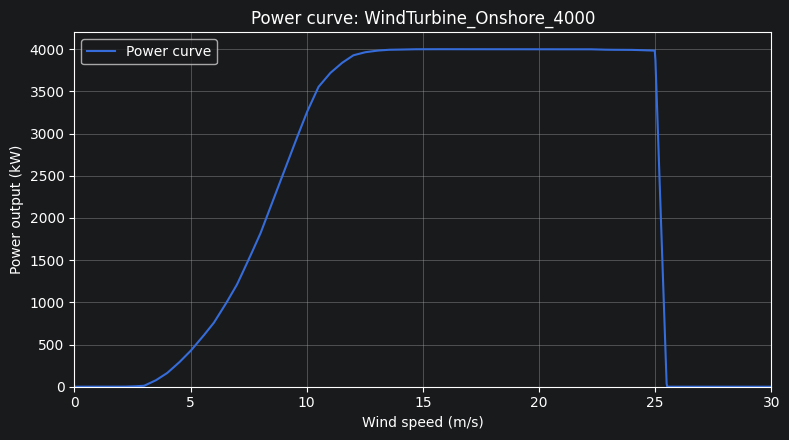

In [96]:
# Vizualize power curve

x_plot = np.linspace(0, 30, 1000)
y_plot = f(x_plot).ravel()

plt.figure(figsize=(8, 4.5))
plt.plot(x_plot, y_plot, label="Power curve")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power output (kW)")
plt.title(f"Power curve: {name}")
plt.legend()
plt.grid(True)
plt.xlim(0, 30)
plt.ylim(0, max(float(rated_capacity) * 1.05, power_output.max() * 1.05))
plt.tight_layout()
plt.show()

In [97]:
# Weather data - DO NOT CHANGE
df = climate_data['dataframe']

if "ws100" in df.columns:
    ws = df["ws100"]
    ws_height = 100
else:
    ws = df["ws10"]
    ws_height = 10

alpha = 1/7

if hubheight > 0:
    ws = ws * (hubheight / ws_height) ** alpha

In [98]:
# defining pv data - DO NOT CHANGE

pv_system_data = dict()
pv_system_data["tilt"] = 18
pv_system_data["surface_azimuth"] = 180
pv_system_data["module_name"] = "SunPower_SPR_X20_327"
pv_system_data["inverter_eff"] = 0.96

inverter_parameters = {
    "pdc0": 5000,
    "eta_inv_nom": pv_system_data["inverter_eff"],
}

In [99]:
# Fitting pv system - DO NOT CHANGE
module_database = pvlib.pvsystem.retrieve_sam("CECMod")
module = module_database[pv_system_data["module_name"]]

temperature_model_parameters = (
    pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS["sapm"][
        "open_rack_glass_glass"
    ]
)

# Create PV model chain
inverter_parameters = {
    "pdc0": 5000,
    "eta_inv_nom": pv_system_data["inverter_eff"],
}

system = pvlib.pvsystem.PVSystem(
    surface_tilt=pv_system_data["tilt"],
    surface_azimuth=pv_system_data["surface_azimuth"],
    module_parameters=module,
    inverter_parameters=inverter_parameters,
    temperature_model_parameters=temperature_model_parameters,
)

# Get location
tz = 'Europe/Amsterdam'

location = pvlib.location.Location(node_lat, node_lon, tz=tz, altitude=node_alt)

pv_model = pvlib.modelchain.ModelChain(
    system, location, spectral_model="no_loss", aoi_model="physical"
)
peakpower = module.STC

In [100]:
# Electricity and L/H Heat, Hydrogen demand data for Point 2
import calendar

skip = sum(calendar.monthrange(year, m)[1] for m in range(1, month)) * 24

demand_data_path = 'data/demand_production.xlsx'
df_p2 = pd.read_excel(demand_data_path, sheet_name='Point2', header=1)

el_demand2 = df_p2['Electricity [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
el_demand2 = el_demand2 * electricity_demand_multiplier

L_heat_demand2 = df_p2['Low T Heat [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
L_heat_demand2 = L_heat_demand2 * heat_demand_multiplier

H_heat_demand2 = df_p2['High T Heat [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
H_heat_demand2 = H_heat_demand2 * heat_demand_multiplier

hydrogen_demand2 = df_p2['H2 Demand [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
hydrogen_demand2 = hydrogen_demand2 * hydrogen_demand_multiplier

In [101]:
# Hydrogen availability at production

H2_available = df_p2['H2 Production [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
H2_available = H2_available * hydrogen_production_multiplier

In [102]:
# Energy production

# Hours to skip to reach the selected month
skip_hours = sum(calendar.monthrange(year, m)[1] for m in range(1, month)) * 24

# wind capacity factor
capacity_factor_wind = f(np.clip(ws.values, 0, 35)) / 4000
capacity_factor_wind = pd.Series(
    np.asarray(capacity_factor_wind).flatten()[skip_hours:skip_hours + len(times)],
    index=times
)

# solar capacity factor
pv_model.run_model(df)
power = pv_model.results.ac.p_mp
capacity_factor_solar = power / peakpower

capacity_factor_solar = pd.Series(
    np.asarray(capacity_factor_solar).flatten()[skip_hours:skip_hours + len(times)],
    index=times
)

/home/krivero/anaconda3/envs/esi_final/lib/python3.13/site-packages/scipy/optimize/_chandrupatla.py:437: RuntimeWarning: invalid value encountered in divide
  C = A / (A + B)


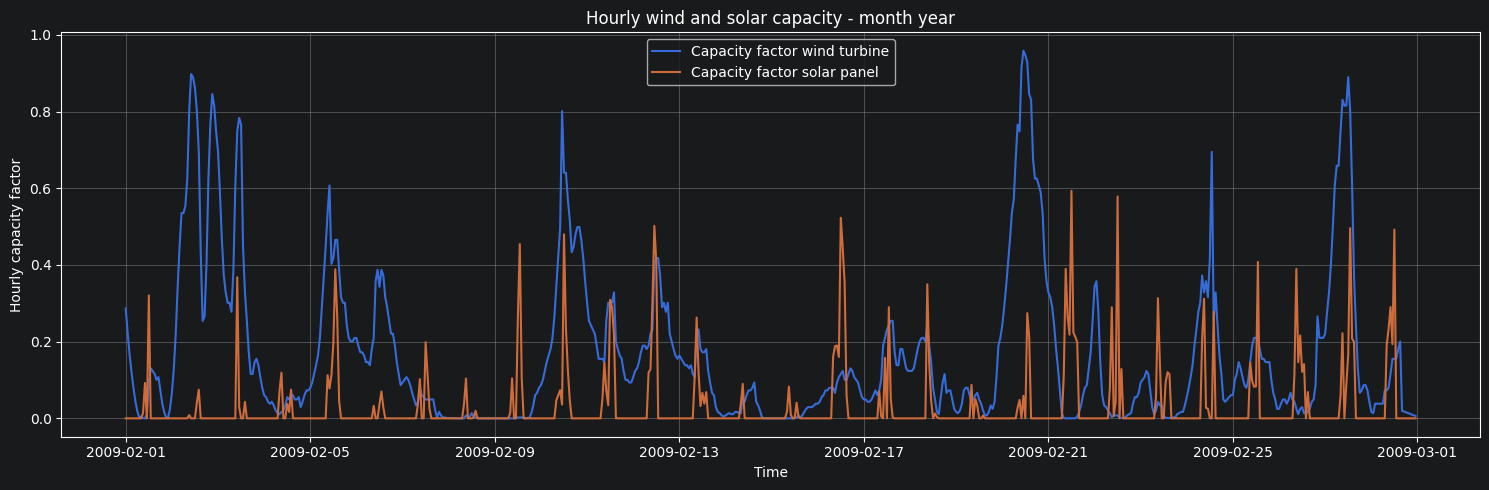

In [103]:
# Plot of capacity factors

plt.figure(figsize=(15, 5))

plt.plot(capacity_factor_wind.index, capacity_factor_wind, label='Capacity factor wind turbine')
plt.plot(capacity_factor_solar.index, capacity_factor_solar, label='Capacity factor solar panel')

plt.xlabel('Time')
plt.ylabel('Hourly capacity factor')
plt.title('Hourly wind and solar capacity - month year')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [104]:
# Obtaining techno-economic data

tech_eco_data_path = 'data/technoeconomic_data.xlsx'
tech_eco_data = pd.read_excel(tech_eco_data_path, sheet_name='Data', header=2)

def get_value(df, component, data_type):
    mask = (df['component'] == component) & (df['parameter'] == data_type)
    result = df.loc[mask, 'value']
    if len(result) == 0:
        raise ValueError(f"No data found for component='{component}', parameter='{data_type}'")
    return result.values[0]

# We give you the wind turbine techno-economic data import as example. Save all the relevant data with the same function
# !!Make sure to use the correct units!!

# Wind turbine
Wind_capex = get_value(tech_eco_data, 'Wind turbine', 'Investment cost')  # EUR/kW
Wind_lifetime = get_value(tech_eco_data, 'Wind turbine', 'Lifetime')  # year
Wind_opex = get_value(tech_eco_data, 'Wind turbine', 'Opex') / 100  # % capex/year

## Start of our Part 2 model code
### Bring in additional techno-economic data

In [105]:
# grab additional techno-economic data
Solar_capex = get_value(tech_eco_data, 'Solar panel', 'Investment cost')  #EUR/kw
Solar_lifetime = get_value(tech_eco_data, 'Solar panel', 'Lifetime') # year
Solar_opex = get_value(tech_eco_data, 'Solar panel', 'Opex') / 100 # % capex/year math included
Electricity_cable_capex = get_value(tech_eco_data, 'Electricity cable', 'Investment cost') #EUR/kw/km
Electricity_cable_lifetime = get_value(tech_eco_data, 'Electricity cable', 'Lifetime') # year
Electricity_cable_fixed_opex = get_value(tech_eco_data, 'Electricity cable', 'Fixed Opex') / 100 # %capex/year
Electricity_cable_losses = get_value(tech_eco_data, 'Electricity cable', 'Losses') / 100 # % per 100km

# relevant for part 2
Hydrogen_pipeline_capex = get_value(tech_eco_data, 'Hydrogen pipeline', 'Investment cost') # Eur/kw/km
Hydrogen_pipeline_lifetime = get_value(tech_eco_data, 'Hydrogen pipeline', 'Lifetime') # year
Hydrogen_pipeline_fixed_opex = get_value(tech_eco_data, 'Hydrogen pipeline', 'Fixed Opex') /100 # % capex/year
Hydrogen_pipeline_losses = get_value(tech_eco_data, 'Hydrogen pipeline', 'Losses') /100 # % per 100km

Li_ion_battery_capex = get_value(tech_eco_data, 'Li-ion battery', 'Investment cost') # EUR/kWh
Li_ion_battery_lifetime = get_value(tech_eco_data, 'Li-ion battery', 'Lifetime') # year
Li_ion_battery_opex = get_value(tech_eco_data, 'Li-ion battery', 'Opex') / 100 # % capex/year
Li_ion_battery_charging_efficiency = get_value(tech_eco_data, 'Li-ion battery', 'Charging efficiency') / 100 # % input energy
Li_ion_battery_discharging_efficiency = get_value(tech_eco_data, 'Li-ion battery', 'Discharging efficiency') / 100 # % output energy
Li_ion_battery_self_discharge_coefficient = get_value(tech_eco_data, 'Li-ion battery', 'Self-discharge coefficient') / 100 # % per hour
Li_ion_battery_max_charging_capacity = get_value(tech_eco_data, 'Li-ion battery', 'Max charging capacity') / 100 # % size of battery
Li_ion_battery_max_discharging_capacity = get_value(tech_eco_data, 'Li-ion battery', 'Max discharging capacity') / 100 # % size of battery

# relevant for part 2
Hydrogen_storage_tank_capex = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Investment cost') # EUR/kWh
Hydrogen_storage_tank_lifetime = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Lifetime') #year
Hydrogen_storage_tank_opex = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Opex') / 100 # % capex/year
Hydrogen_storage_tank_charging_efficiency = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Charging efficiency') / 100 # % input energy
Hydrogen_storage_tank_discharging_efficiency = get_value(tech_eco_data, 'Hydrogen storage - tank','Discharging efficiency') # error in data this does not need division by 100 % output energy
Hydrogen_storage_tank_self_discharge_coefficient = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Self-discharge coefficient') / 100# %/hour
Hydrogen_storage_tank_max_charging_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max charging capacity') / 100 # %/size
Hydrogen_storage_tank_max_discharging_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max discharging capacity') / 100 # %/size
Hydrogen_storage_tank_max_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max capacity') # MW

Heat_storage_high_temp_capex = get_value(tech_eco_data, 'Heat storage - High temp', 'Investment cost') # EUR/MWh
Heat_storage_high_temp_lifetime = get_value(tech_eco_data, 'Heat storage - High temp', 'Lifetime') # year
Heat_storage_high_temp_opex = get_value(tech_eco_data, 'Heat storage - High temp', 'Opex') / 100 # % capex/year
Heat_storage_high_temp_charging_efficiency = get_value(tech_eco_data, 'Heat storage - High temp', 'Charging efficiency') / 100 # % input energy
Heat_storage_high_temp_discharging_efficiency = get_value(tech_eco_data, 'Heat storage - High temp','Discharging efficiency') / 100 # % output energy
Heat_storage_high_temp_self_discharge_coefficient = get_value(tech_eco_data, 'Heat storage - High temp', 'Self-discharge coefficient') # % / hour
Heat_storage_high_temp_max_charging_capacity = get_value(tech_eco_data, 'Heat storage - High temp', 'Max charging capacity') / 100 # % size
Heat_storage_high_temp_max_discharging_capacity = get_value(tech_eco_data, 'Heat storage - High temp', 'Max discharging capacity') / 100 # % size

Heat_storage_low_temp_capex = get_value(tech_eco_data, 'Heat storage - Low temp', 'Investment cost') # EUR/MWh
Heat_storage_low_temp_lifetime = get_value(tech_eco_data, 'Heat storage - Low temp', 'Lifetime') # year
Heat_storage_low_temp_opex = get_value(tech_eco_data, 'Heat storage - Low temp', 'Opex') /100 # % capex/year
Heat_storage_low_temp_charging_efficiency = get_value(tech_eco_data, 'Heat storage - Low temp', 'Charging efficiency') / 100 # % input energy
Heat_storage_low_temp_discharging_efficiency = get_value(tech_eco_data, 'Heat storage - Low temp','Discharging efficiency') / 100# % output energy
Heat_storage_low_temp_self_discharge_coefficient = get_value(tech_eco_data, 'Heat storage - Low temp', 'Self-discharge coefficient') / 100 # % / hour
Heat_storage_low_temp_max_charging_capacity = get_value(tech_eco_data, 'Heat storage - Low temp', 'Max charging capacity') / 100 # % size
Heat_storage_low_temp_max_discharging_capacity = get_value(tech_eco_data, 'Heat storage - Low temp', 'Max discharging capacity') / 100 # % size

Heat_pump_coefficient_of_performance = get_value(tech_eco_data, 'Heat pump', 'COP') # no unit
Hydrogen_boiler_efficiency = get_value(tech_eco_data, 'Hydrogen boiler', 'Efficiency') / 100 # % input energy
Operational_cost_lost_load_penalty = get_value(tech_eco_data, 'Operational cost', 'Lost load penalty') # EUR/MWh
Operational_cost_max_import_availability = get_value(tech_eco_data, 'Operational cost', 'Max import availability') # MWh
Operational_cost_electricity_import_cost = get_value(tech_eco_data, 'Operational cost', 'Electricity import cost') # EUR/MWh
Operational_cost_hydrogen_market_price = get_value(tech_eco_data, 'Operational cost', 'Hydrogen market price') # EUR/MWh


## PyPSA Model for Part 2 - Scenario X
The code below is shared as an exemple of the PyPSA model structure used for analysis of the Part 2 design. Different scenarios were made with different choices in the model parameters to encourage different results in the KPIs of system cost, RES curtailment, utilization factor of the line, and unserved demand. Continue to the ***Comparison Section*** for comparison across scenarios.

In [106]:
# PyPSA Part 2 Model roughly following 3-node expansion example
# https://docs.pypsa.org/latest/examples/3-node-cem/

import cartopy.crs as ccrs
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pypsa
from pypsa.costs import annuity

# data prep and variables

# p_nom_min_solar = 50
marginal_cost_wind = 0 # gave 0 here. assumed included in opex
marginal_cost_solar = 0

# Battery parameters
p_nom_bat_guess = 10  # MW, initial guess
max_p_nom_batt = 500
# battery_energy_capacity = 25  # MWh, from your Li-ion spec
# battery_max_hours = battery_energy_capacity / p_nom_guess
eta_charge = Li_ion_battery_charging_efficiency # eta is efficiency
eta_discharge = Li_ion_battery_discharging_efficiency
max_charge_pu = Li_ion_battery_max_charging_capacity

#transmission
efficiency_transmission_12 = (1 - Electricity_cable_losses) ** (distance12 / 100)  # = 0.9737 for 53km
efficiency_transmission_23 = (1 - Hydrogen_pipeline_losses) ** (distance23 / 100)

# H2
p_nom_h2 = H2_available.max()
H2_available = H2_available.copy()
H2_available.index = pd.to_datetime(times)
H2_available.index = H2_available.index.tz_localize(None)
p_max_pu_h2 = H2_available / p_nom_h2

# annualize the CAPEX
r = 0.05
simulation_hours = len(times)
monthly_annualizer= simulation_hours/8760

annualized_capex_wind = (Wind_capex*1000) * annuity(r, Wind_lifetime)
annualized_capex_solar = (Solar_capex*1000) * annuity(r, Solar_lifetime)
# annualized_capex_wind_manual = 80600 # eur/MW/y
# annualized_capex_solar_manual = 34200 # eur/MW/y
max_hours_bat = 4 #
annualized_capex_battery = (Li_ion_battery_capex*1000) * max_hours_bat * annuity(r, Li_ion_battery_lifetime) #eur/Mwh * h * annuity = eur/MW

annualized_capex_hydrogen_storage = (Hydrogen_storage_tank_capex*1000) * annuity(r, Hydrogen_storage_tank_lifetime) #eur/MWh # unlike battery PyPSA wants this in MWh, for energy capacity
annualized_capex_heat_high_storage = (Heat_storage_high_temp_capex) * annuity(r, Heat_storage_high_temp_lifetime) # capex already in MWh
annualized_capex_heat_low_storage = (Heat_storage_low_temp_capex) * annuity(r, Heat_storage_low_temp_lifetime)
# capital_cost_power ≈ (1 / C_rate) × capital_cost_energy
heat_high_charge_capex = (1/Heat_storage_high_temp_max_charging_capacity)*Heat_storage_high_temp_capex
heat_low_charge_capex = (1/Heat_storage_low_temp_max_charging_capacity)*Heat_storage_low_temp_capex
#discharge is same %

annualized_capex_transmission = (Electricity_cable_capex*1000) * distance12 * annuity(r, Electricity_cable_lifetime) # Eur/kw/km * 1000 * km
annualized_capex_pipeline = (Hydrogen_pipeline_capex*1000) * distance23 * annuity(r, Hydrogen_pipeline_lifetime) # eur/kW/km * 1000 * km

#annualize the OPEX
annualized_opex_wind = (Wind_capex * 1000) * Wind_opex  # overnight capex * % = €/MW/year
annualized_opex_solar = (Solar_capex * 1000) * Solar_opex
annualized_opex_battery = (Li_ion_battery_capex * 1000) * Li_ion_battery_opex

annualized_opex_hydrogen_storage = (Hydrogen_storage_tank_capex*1000) * Hydrogen_storage_tank_opex
annualized_opex_heat_high_storage = (Heat_storage_high_temp_capex) * Heat_storage_high_temp_opex # in MWh already so no convert
annualized_opex_heat_low_storage = (Heat_storage_low_temp_capex) * Heat_storage_low_temp_opex

annualized_opex_transmission = (Electricity_cable_capex* 1000) * distance12 * Electricity_cable_fixed_opex # fixme is fixed different?
annualized_opex_pipeline = (Hydrogen_pipeline_capex* 1000) * distance23 * Hydrogen_pipeline_fixed_opex

capital_cost_solar = (annualized_capex_solar + annualized_opex_solar)*monthly_annualizer
capital_cost_wind = (annualized_capex_wind + annualized_opex_wind)*monthly_annualizer
capital_cost_battery = (annualized_capex_battery + annualized_opex_battery)*monthly_annualizer #confusion around whether multiplying by max hours is needed but I think correct
capital_cost_hydrogen_storage = (annualized_capex_hydrogen_storage + annualized_opex_hydrogen_storage)*monthly_annualizer
capital_cost_heat_high_storage = (annualized_capex_heat_high_storage + annualized_opex_heat_high_storage) * monthly_annualizer
capital_cost_heat_low_storage = (annualized_capex_heat_low_storage + annualized_opex_heat_low_storage) * monthly_annualizer
capital_cost_transmission = (annualized_capex_transmission + annualized_opex_transmission)*monthly_annualizer
capital_cost_pipeline = (annualized_capex_pipeline + annualized_opex_pipeline) * monthly_annualizer

# conversions timestamp based index vs. integer, repulling from df_p2 so need to re-multiply
el_demand2 = df_p2['Electricity [MWh]'].iloc[skip : skip + len(times)]
el_demand2 = el_demand2.set_axis(times)
el_demand2 = el_demand2 * electricity_demand_multiplier
el_demand2.index = pd.to_datetime(el_demand2.index).tz_localize(None)

L_heat_demand2 = df_p2['Low T Heat [MWh]'].iloc[skip : skip + len(times)]
L_heat_demand2 = L_heat_demand2.set_axis(times)
L_heat_demand2 = L_heat_demand2 * heat_demand_multiplier
L_heat_demand2.index = pd.to_datetime(L_heat_demand2.index).tz_localize(None)

H_heat_demand2 = df_p2['High T Heat [MWh]'].iloc[skip : skip + len(times)]
H_heat_demand2 = H_heat_demand2.set_axis(times)
H_heat_demand2 = H_heat_demand2 * heat_demand_multiplier
H_heat_demand2.index = pd.to_datetime(H_heat_demand2.index).tz_localize(None)

hydrogen_demand2 = df_p2['H2 Demand [MWh]'].iloc[skip : skip + len(times)]
hydrogen_demand2 = hydrogen_demand2.set_axis(times)
hydrogen_demand2 = hydrogen_demand2 * hydrogen_demand_multiplier
hydrogen_demand2.index = pd.to_datetime(hydrogen_demand2.index).tz_localize(None)

H2_available = df_p2['H2 Production [MWh]'].iloc[skip : skip + len(times)]
H2_available = H2_available.set_axis(times)
H2_available = H2_available * hydrogen_production_multiplier
H2_available.index = pd.to_datetime(H2_available.index).tz_localize(None)

capacity_factor_wind.index = pd.to_datetime(capacity_factor_wind.index).tz_localize(None)
capacity_factor_solar.index = pd.to_datetime(capacity_factor_solar.index).tz_localize(None)

ts = pd.concat(
    [
        el_demand2.rename("e_load_mw"),
        L_heat_demand2.rename("l_heat_load"),
        H_heat_demand2.rename("h_heat_load"),
        hydrogen_demand2.rename("hydrogen_demand"),
        H2_available.rename("H2_available"),
        capacity_factor_wind.rename("wind_pu"),
        capacity_factor_solar.rename("solar_pu"),
    ],
    axis=1
)

# sanity check
assert len(ts) == len(times), f"Time series length mismatch: {len(ts)} vs {len(times)}"

#network setup
RESOLUTION = 1 # hourly
n = pypsa.Network()
ts.index = ts.index.tz_localize(None)
n.set_snapshots(ts.index)
n.snapshot_weightings.loc[:, :] = RESOLUTION

REGIONS = ["zone1", "zone2", "zone3"]

REGION_COORDS = {
    "zone1": {"lat": node_lat, "lon": node_lon},
    "zone2": {"lat": 54.279,  "lon": 10.164},
    "zone3": {"lat": 54.279,  "lon": 11.691},
}

REGION_CARRIERS = {
    "zone1": ["electricity"],
    "zone2": ["electricity", "heat_low_temp", "heat_high_temp", "hydrogen"],
    "zone3": ["hydrogen"],
}

#creating buses per region and carrier e.g. zone1_electricity
for region in REGIONS:
    for carrier in REGION_CARRIERS[region]:
        bus_name = f"{region}_{carrier}"

        n.add(
            "Bus",
            bus_name,
            carrier=carrier,
            x=REGION_COORDS[region]["lon"],
            y=REGION_COORDS[region]["lat"],
        )

def bus(region, carrier):
    assert region in REGIONS
    assert carrier in REGION_CARRIERS[region]
    return f"{region}_{carrier}"

carriers = [
    # Energy carriers (core system)
    "electricity",
    "heat_low_temp",
    "heat_high_temp",
    "hydrogen",

    # Generation
    "wind",
    "solar",

    # Storage
    "battery",
    "hydrogen storage",
    "heat_low_storage",
    "heat_high_storage",

    # Conversion / system
    # "electrolysis",
    "heat pump",
    "h2 boiler",

    # Other
    "hydrogen pipeline",
    "load shedding",
    "imported electricity",
]
colors = [
    # Energy carriers (core system)
    "white",           # electricity
    "lightsalmon",     # heat_low_temp
    "orangered",       # heat_high_temp
    "purple",          # hydrogen

    # Generation
    "dodgerblue",      # wind
    "gold",            # solar

    # Storage
    "darkorange",      # battery
    "mediumpurple",    # hydrogen storage
    "lightcoral",      # heat_low_storage
    "tomato",          # heat_high_storage

    # Conversion / system
    "green",           # heat pump
    "orchid",          # h2 boiler

    # Other
    "lightblue",       # hydrogen pipeline
    "red",             # load shedding
    "lightgreen",      # imported electricity
]
n.add("Carrier", carriers, color=colors)

# COMPONENTS SECTION
# GENERATION
n.add(
    "Generator",
    "solar_zone1",
    bus=bus("zone1", "electricity"),
    carrier="solar",
    p_max_pu=ts.solar_pu,
    capital_cost=capital_cost_solar, # using MW
    marginal_cost=marginal_cost_solar,
    p_nom_extendable=True, #note allows PyPSA optimization to choose how much capacity to build
)

n.add("Generator",
    "wind_zone1",
    bus=bus("zone1", "electricity"),
    carrier="wind",
    p_max_pu=ts.wind_pu,
    capital_cost=capital_cost_wind, # using MW
    marginal_cost=marginal_cost_wind,
    p_nom_extendable=True, #note allows PyPSA optimization to choose how much capacity to build
)

n.add(
    "Generator",
    "load shedding",
    bus=bus("zone2", "electricity"),
    carrier="load shedding",
    marginal_cost=Operational_cost_lost_load_penalty,
    p_nom=ts.e_load_mw.max(),
    # p_max_pu=0.05,  # at any hour, max shedding = 5% of p_nom
)

n.add(
    "Generator",
    "import",
    bus=bus("zone2", "electricity"),
    carrier="imported electricity",
    marginal_cost=Operational_cost_electricity_import_cost,        # existing variable, €/MWh
    p_nom=Operational_cost_max_import_availability,    # existing variable, MW
    p_nom_extendable=False, # can't expand capacity any more than max
)

n.add(
    "Generator",
    "h2_zone3",
    bus=bus("zone3", "hydrogen"),
    carrier="hydrogen",
    p_nom=p_nom_h2,
    p_max_pu=p_max_pu_h2,
    marginal_cost=Operational_cost_hydrogen_market_price, # eur/MWh
)

n.add("Generator", "loadshed_hydrogen",
    bus=bus("zone2", "hydrogen"),
    carrier="load shedding",
    marginal_cost=Operational_cost_lost_load_penalty,
    p_nom=ts.hydrogen_demand.max())

n.add("Generator", "loadshed_heat_high",
    bus=bus("zone2", "heat_high_temp"),
    carrier="load shedding",
    marginal_cost=Operational_cost_lost_load_penalty,
    p_nom=ts.h_heat_load.max()
)

n.add("Generator", "loadshed_heat_low",
    bus=bus("zone2", "heat_low_temp"),
    carrier="load shedding",
    marginal_cost=Operational_cost_lost_load_penalty,
    p_nom=ts.l_heat_load.max()
)

# DEMAND
# Electricity demand
n.add(
    "Load",
    "electricity_demand",
    bus=bus("zone2", "electricity"),
    carrier="electricity",
    p_set=ts.e_load_mw,
)

# Low-temperature heat demand
n.add(
    "Load",
    "heat_low_demand",
    bus=bus("zone2", "heat_low_temp"),
    carrier="heat_low_temp",
    p_set=ts.l_heat_load,   # make sure this is your low-temp heat time series
)

# High-temperature heat demand
n.add(
    "Load",
    "heat_high_demand",
    bus=bus("zone2", "heat_high_temp"),
    carrier="heat_high_temp",
    p_set=ts.h_heat_load,  # make sure this is your high-temp heat time series
)

# Hydrogen demand
n.add(
    "Load",
    "hydrogen_demand",
    bus=bus("zone2", "hydrogen"),
    carrier="hydrogen",
    p_set=ts.hydrogen_demand,  # hydrogen demand in MW
)

# STORAGE
n.add(
    "StorageUnit",
    "battery storage zone 1", # manually swap batteries
    bus=bus("zone1", "electricity"),
    carrier="battery",
    p_nom=p_nom_bat_guess, #MW
    p_nom_extendable=True,
    p_nom_max=max_p_nom_batt,
    max_hours=max_hours_bat, # E_max = p_nom * max_hours battery can go 4 hours at full discharge
    capital_cost=capital_cost_battery,
    efficiency_store=eta_charge,
    efficiency_dispatch=eta_discharge,
    standing_loss=Li_ion_battery_self_discharge_coefficient,
    p_max_pu=max_charge_pu,    # max discharge capacity = 50% of p_nom
    p_min_pu=-max_charge_pu,   # max charge capacity = 50% of p_nom (note: negative = charging)
    state_of_charge_initial=0.5 * p_nom_bat_guess * max_hours_bat,
)

# n.add(
#     "StorageUnit",
#     "battery storage zone 2", #manually swap in
#     bus="zone2",
#     carrier="battery storage",
#     p_nom=p_nom_guess, #MW
#     # max_hours=e_nom/p_nom, # E_max = p_nom * max_hours battery can go 3 hours at full discharge
#     capital_cost=capital_cost_battery,
#     efficiency_store=eta_charge,
#     efficiency_dispatch=eta_discharge,
#     standing_loss=0.00004,
#     p_max_pu=max_charge_pu,    # max discharge capacity = 50% of p_nom
#     p_min_pu=-max_charge_pu,   # max charge capacity = 50% of p_nom (note: negative = charging)
#     e_nom_extendable=True, # allowing capacity to increase in MWh
#     cyclic_state_of_charge=True, #The battery’s state of charge at the end of the simulation equals its starting state. Ensures no net energy accumulation over the optimization horizon. Important for representing a full year or cyclic operation
# )

#h2 storage section - note requires accompanying links to account for charge/discharge parameters
n.add(
    "Bus",
    "h2_storage_internal",
    carrier="hydrogen",
)

n.add(
    "Store",
    "h2_storage_zone3",
    bus="h2_storage_internal",
    carrier="hydrogen storage",
    e_nom_extendable=True,
    e_nom_max = Hydrogen_storage_tank_max_capacity,
    capital_cost=capital_cost_hydrogen_storage,
    e_cyclic=True,           # optional: end level = start level
    standing_loss=Hydrogen_storage_tank_self_discharge_coefficient
)

n.add(
    "Link",
    "h2_charge_zone3",
    bus0=bus("zone3", "hydrogen"),
    bus1="h2_storage_internal",
    efficiency=Hydrogen_storage_tank_charging_efficiency,
    p_nom=Hydrogen_storage_tank_max_charging_capacity * Hydrogen_storage_tank_max_capacity,   # MW = % * MWh assuming % was hourly c-rate
    carrier="hydrogen storage",
)

n.add(
    "Link",
    "h2_discharge_zone3",
    bus0="h2_storage_internal",
    bus1=bus("zone3", "hydrogen"),
    efficiency=Hydrogen_storage_tank_discharging_efficiency,
    p_nom=Hydrogen_storage_tank_max_discharging_capacity * Hydrogen_storage_tank_max_capacity,  # MW = % * MWh assuming % was hourly crate
    carrier="hydrogen storage",
)

# heat storage section
n.add(
    "Bus",
    "heat_low_storage_internal",
    carrier="heat_low_temp",
)

n.add(
    "Bus",
    "heat_high_storage_internal",
    carrier="heat_high_temp",
)

n.add(
    "Store",
    "heat_low_storage",
    bus="heat_low_storage_internal",
    carrier="heat_low_storage",
    e_nom=0,
    e_nom_extendable=True,
    standing_loss=Heat_storage_low_temp_self_discharge_coefficient,
    capital_cost=capital_cost_heat_low_storage,
    e_cyclic=True,
)

n.add(
    "Store",
    "heat_high_storage",
    bus="heat_high_storage_internal",
    carrier="heat_high_storage",
    e_nom=0,
    e_nom_extendable=True,
    standing_loss=Heat_storage_high_temp_self_discharge_coefficient,
    capital_cost=capital_cost_heat_high_storage,
    e_cyclic=True,
)

n.add(
    "Link",
    "heat_low_charge",
    bus0=bus("zone2", "heat_low_temp"),
    bus1="heat_low_storage_internal",
    efficiency=Heat_storage_low_temp_charging_efficiency,
    p_nom_extendable=True,
    capital_cost=heat_low_charge_capex, #workaround for max charging capacity inclusion
    carrier="heat_low_storage",
)

n.add(
    "Link",
    "heat_low_discharge",
    bus0="heat_low_storage_internal",
    bus1=bus("zone2", "heat_low_temp"),
    efficiency=Heat_storage_low_temp_discharging_efficiency,
    p_nom_extendable=True,
    capital_cost=heat_low_charge_capex, #same rate for discharge
    carrier="heat_low_storage",
)

n.add(
    "Link",
    "heat_high_charge",
    bus0=bus("zone2", "heat_high_temp"),
    bus1="heat_high_storage_internal",
    efficiency=Heat_storage_high_temp_charging_efficiency,
    p_nom_extendable=True,
    capital_cost=heat_high_charge_capex,
    carrier="heat_high_storage",
)

n.add(
    "Link",
    "heat_high_discharge",
    bus0="heat_high_storage_internal",
    bus1=bus("zone2", "heat_high_temp"),

    efficiency=Heat_storage_high_temp_discharging_efficiency,
    p_nom_extendable=True,
    capital_cost=heat_high_charge_capex,
    carrier="heat_high_storage",
)

#TRANSMISSION
# Electricity line from zone1 to zone2
n.add(
    "Link",
    "zone1-zone2",
    bus0=bus("zone1", "electricity"),
    bus1=bus("zone2", "electricity"),
    efficiency=efficiency_transmission_12,
    # p_nom = p_nom_guess # MW max capacity if fixed
    p_nom_extendable=True,        # allows optimization
    capital_cost=capital_cost_transmission,  # €/MW
    carrier="electricity",
)

#h2 pipeline
# Hydrogen pipeline from zone3 to zone2
n.add(
    "Link",
    "zone3-zone2",
    bus0=bus("zone3", "hydrogen"),
    bus1=bus("zone2", "hydrogen"),
    efficiency=efficiency_transmission_23,
    p_nom_extendable=True,  # optimize pipeline capacity
    capital_cost=capital_cost_pipeline,  # €/MW
    carrier="hydrogen pipeline",
)

#CONVERSION
n.add(
    "Link",
    "heatpump_zone2",
    bus0=bus("zone2", "electricity"),
    bus1=bus("zone2", "heat_low_temp"),
    efficiency=Heat_pump_coefficient_of_performance,
    p_nom_extendable=True,      # lets PyPSA choose size
    # capital_cost=capital_cost_heatpump,  # €/MW_electricity input assume preexisting infra no cost
    carrier="heat pump",
)

n.add(
    "Link",
    "h2_boiler_zone2",
    bus0=bus("zone2", "hydrogen"),
    bus1=bus("zone2", "heat_high_temp"),
    efficiency=Hydrogen_boiler_efficiency,   # fraction of H2 energy converted to heat
    p_nom_extendable=True,              # size is optimized
    # capital_cost=capital_cost_h2_boiler, # assumed this is preexisting infra so no cost
    carrier="h2 boiler",
)

for bus_name in n.buses.index:
    loads = n.loads[n.loads.bus == bus_name].index.tolist()
    gens = n.generators[n.generators.bus == bus_name].index.tolist()
    links_in = n.links[n.links.bus1 == bus_name].index.tolist()
    if loads and not gens and not links_in:
        print(f"ISOLATED: {bus_name} has demand but no supply path")

n.optimize()

/tmp/ipykernel_5447/1063132280.py:546: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 12/12 [00:00<00:00, 339.40it/s]
INFO:linopy.io: Writing time: 0.22s


Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-1c_2mjpi has 41008 rows; 18159 cols; 73376 nonzeros
Coefficient ranges:
  Matrix  [1e-04, 4e+00]
  Cost    [1e+00, 3e+05]
  Bound   [1e+05, 1e+05]
  RHS     [8e-01, 5e+02]
Presolving model
17585 rows, 17597 cols, 48050 nonzeros  0s
Dependent equations search running on 6672 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
15521 rows, 15533 cols, 43987 nonzeros  0s
Presolve reductions: rows 15521(-25487); columns 15533(-2626); nonzeros 43987(-29389) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.0441856169e+05 Pr: 2690(41531.3) 0.1s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 18159 primals, 41008 duals
Objective: 1.06e+07
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


      12544     1.0602523543e+07 Pr: 0(0); Du: 0(4.15049e-13) 1.9s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-1c_2mjpi
Model status        : Optimal
Simplex   iterations: 12544
Objective value     :  1.0602523543e+07
P-D objective error :  8.7839704097e-17
HiGHS run time      :          1.91


('ok', 'optimal')

In [107]:
# for the example scenario
n.statistics()

Optimal Capacity  Installed Capacity  \
Generator   hydrogen                      39.84930             39.8493   
            imported electricity          25.00000             25.0000   
            load shedding                 93.11060             93.1106   
            solar                         37.52754              0.0000   
            wind                         109.26628              0.0000   
Link        electricity                   37.11023              0.0000   
            h2 boiler                     24.43252              0.0000   
            heat pump                     10.61802              0.0000   
            hydrogen pipeline             33.49699              0.0000   
            hydrogen storage             100.00000            100.0000   
Load        electricity                    0.00000              0.0000   
            heat_high_temp                 0.00000              0.0000   
            heat_low_temp                  0.00000              0.0000   
            hydrogen                       0.00000              0.0000   
StorageUnit battery                       34.42872             10.0000   
Store       hydrogen storage             100.00000              0.0000   

                                       Supply   Withdrawal  Energy Balance  \
Generator   hydrogen              15313.34087      0.00000     15313.34087   
            imported electricity   8569.22203      0.00000      8569.22203   
            load shedding          2708.58257      0.00000      2708.58257   
            solar                   678.50045      0.00000       678.50045   
            wind                   9856.04364      0.00000      9856.04364   
Link        electricity               0.00000  10498.50501    -10498.50501   
            h2 boiler                 0.00000   9531.52256     -9531.52256   
            heat pump                 0.00000   5927.33497     -5927.33497   
            hydrogen pipeline         0.00000  15229.44557    -15229.44557   
            hydrogen storage          0.00000   1286.46322     -1286.46322   
Load        electricity               0.00000  12871.89984    -12871.89984   
            heat_high_temp            0.00000   8891.00246     -8891.00246   
            heat_low_temp             0.00000  20745.67241    -20745.67241   
            hydrogen                  0.00000   5562.30612     -5562.30612   
StorageUnit battery                1061.14611   1097.18519       -36.03908   
Store       hydrogen storage        601.28396    602.95775        -1.67379   

                                  Transmission  Capacity Factor  Curtailment  \
Generator   hydrogen                   0.00000         0.571847   1905.27792   
            imported electricity       0.00000         0.510073   8230.77797   
            load shedding              0.00000         0.043289  59861.73912   
            solar                      0.00000         0.026905    178.65166   
            wind                       0.00000         0.134229   2552.45100   
Link        electricity            10498.50501         0.420983      0.00000   
            h2 boiler                  0.00000         0.580530      0.00000   
            heat pump                  0.00000         0.830705      0.00000   
            hydrogen pipeline      15229.44557         0.676564      0.00000   
            hydrogen storage        1286.46322         0.019144      0.00000   
Load        electricity                0.00000              NaN      0.00000   
            heat_high_temp             0.00000              NaN      0.00000   
            heat_low_temp              0.00000              NaN      0.00000   
            hydrogen                   0.00000              NaN      0.00000   
StorageUnit battery                    0.00000         0.093288  11604.08999   
Store       hydrogen storage           0.00000         0.311345      0.00000   

                                  Capital Expenditure  \
Generator   hydrogen          

## Comparison Section - Part 2
In the cells below we compare multiple scenarios across the directed KPIs: RES curtailment, unserved demand across energy types, conversion and transport losses (for non electric), total additional cost, transmission utilization for L12, number of hours that L32 is at max capacity, number of hours H2 reservoir is empty or full. (binding storage constraints).

In our models we ran a number of scenarios to investigate the relationship between design parameters and numerous KPIs. The parameter configurations of each scenario can be found here:
https://docs.google.com/spreadsheets/d/1TDLvnTkoasLHzYvYxa_W-6mtMj7YGGRmXB0ouGcNCcE/edit?gid=0#gid=0

### What is our dataset like?
Our Part 2 dataset corresponds to the same location on the Jutland peninsula in Northern Germany in the month February. The demand landscape is more complicated than Part 1. We have electricity demand, but also have demand for high and low temperature heat, as well as hydrogen.

Our primary challenge is that our given multipliers result in demand and production figures for H2 that are roughly equivalent, with a slim margin of 200 MWh production. This slim margin presents a serious timing mismatch challenge. The chart below shows how little opportunity there is for storage.

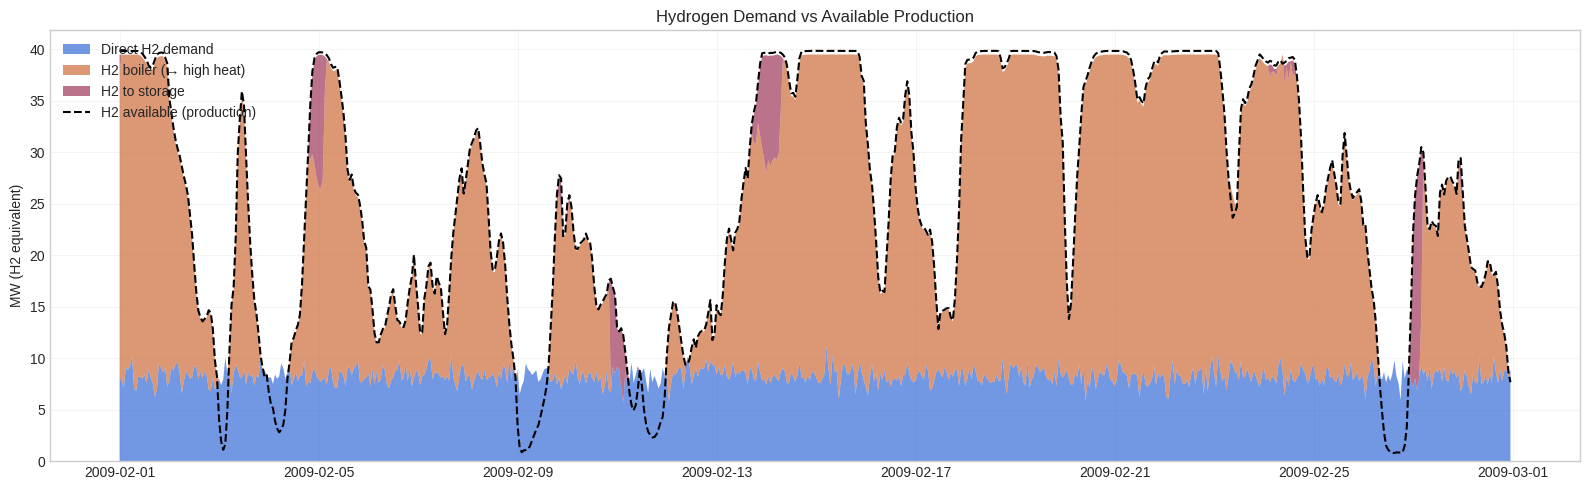

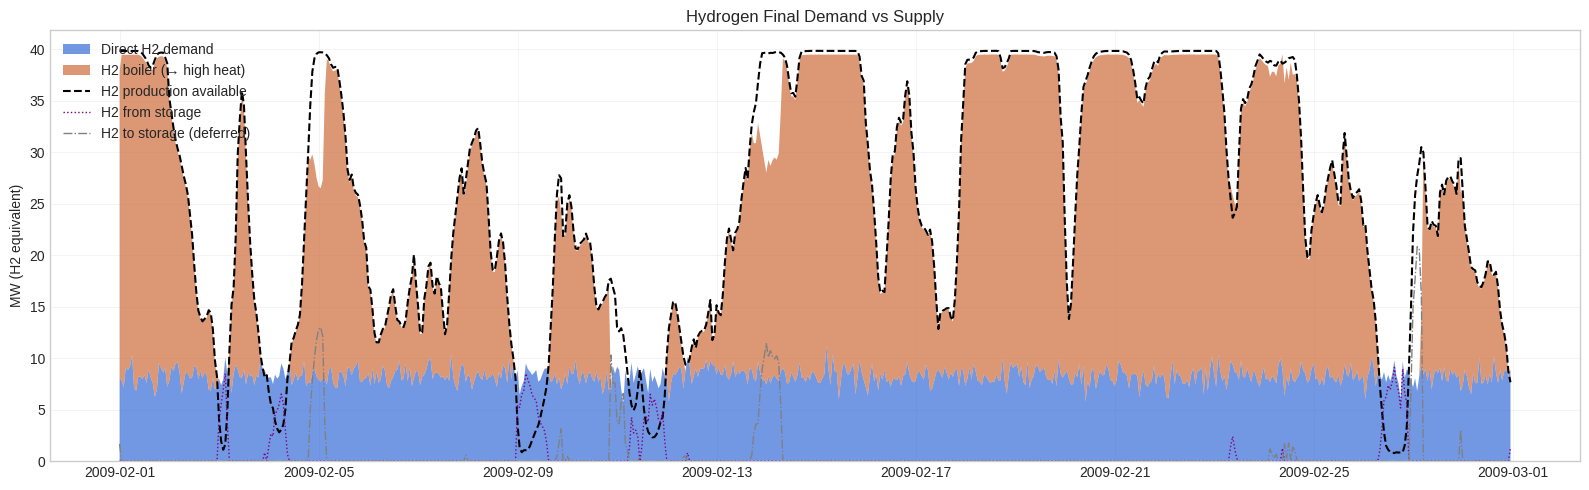

Total H2 available:        17218.6 MWh
Total direct H2 demand:    5562.3 MWh
Total H2 to boiler:        11456.1 MWh
Total H2 to storage:       358.2 MWh
Total H2 demand:           17376.6 MWh
Gap (available - demand):  200.2 MWh


In [124]:
import matplotlib.pyplot as plt

# Supply side
h2_available = ts.H2_available  # raw H2 production available (MW)

# Demand side
h2_direct_demand = ts.hydrogen_demand                          # direct H2 demand at zone2

# H2 consumed by boiler (p0 = H2 input side)
h2_boiler_consumption = n.links_t.p0["h2_boiler_zone2"]

# H2 consumed charging zone3 storage (p0 = H2 input)
h2_to_storage = n.links_t.p0["h2_charge_zone3"]

# Total H2 demand stack
h2_total_demand = h2_direct_demand + h2_boiler_consumption + h2_to_storage

# Plot
fig, ax = plt.subplots(figsize=(16, 5))

ax.stackplot(
    ts.index,
    h2_direct_demand,
    h2_boiler_consumption,
    h2_to_storage,
    labels=["Direct H2 demand", "H2 boiler (→ high heat)", "H2 to storage"],
    alpha=0.7,
)

ax.plot(ts.index, h2_available, color="black", linewidth=1.5,
        linestyle="--", label="H2 available (production)")

ax.set_ylabel("MW (H2 equivalent)")
ax.set_title("Hydrogen Demand vs Available Production")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(16, 5))

# Final demand only
ax.stackplot(
    ts.index,
    h2_direct_demand,
    h2_boiler_consumption,
    labels=["Direct H2 demand", "H2 boiler (→ high heat)"],
    alpha=0.7,
)

# Supply = production available (before storage routing)
ax.plot(ts.index, h2_available, color="black", linewidth=1.5,
        linestyle="--", label="H2 production available")

# Storage discharge as additional supply
h2_from_storage = -n.links_t.p1["h2_discharge_zone3"]  # p1 is negative, flip sign
ax.plot(ts.index, h2_from_storage, color="purple", linewidth=1,
        linestyle=":", label="H2 from storage")

# Storage charging as a separate reference line (not part of demand stack)
ax.plot(ts.index, h2_to_storage, color="grey", linewidth=1,
        linestyle="-.", label="H2 to storage (deferred)")

ax.set_ylabel("MW (H2 equivalent)")
ax.set_title("Hydrogen Final Demand vs Supply")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Summary
print(f"Total H2 available:        {h2_available.sum():.1f} MWh")
print(f"Total direct H2 demand:    {h2_direct_demand.sum():.1f} MWh")
print(f"Total H2 to boiler:        {h2_boiler_consumption.sum():.1f} MWh")
print(f"Total H2 to storage:       {h2_to_storage.sum():.1f} MWh")
print(f"Total H2 demand:           {h2_total_demand.sum():.1f} MWh")
print(f"Gap (available - demand):  {(h2_available.sum() - h2_total_demand.sum() + h2_to_storage.sum() ):.1f} MWh")

Load Data

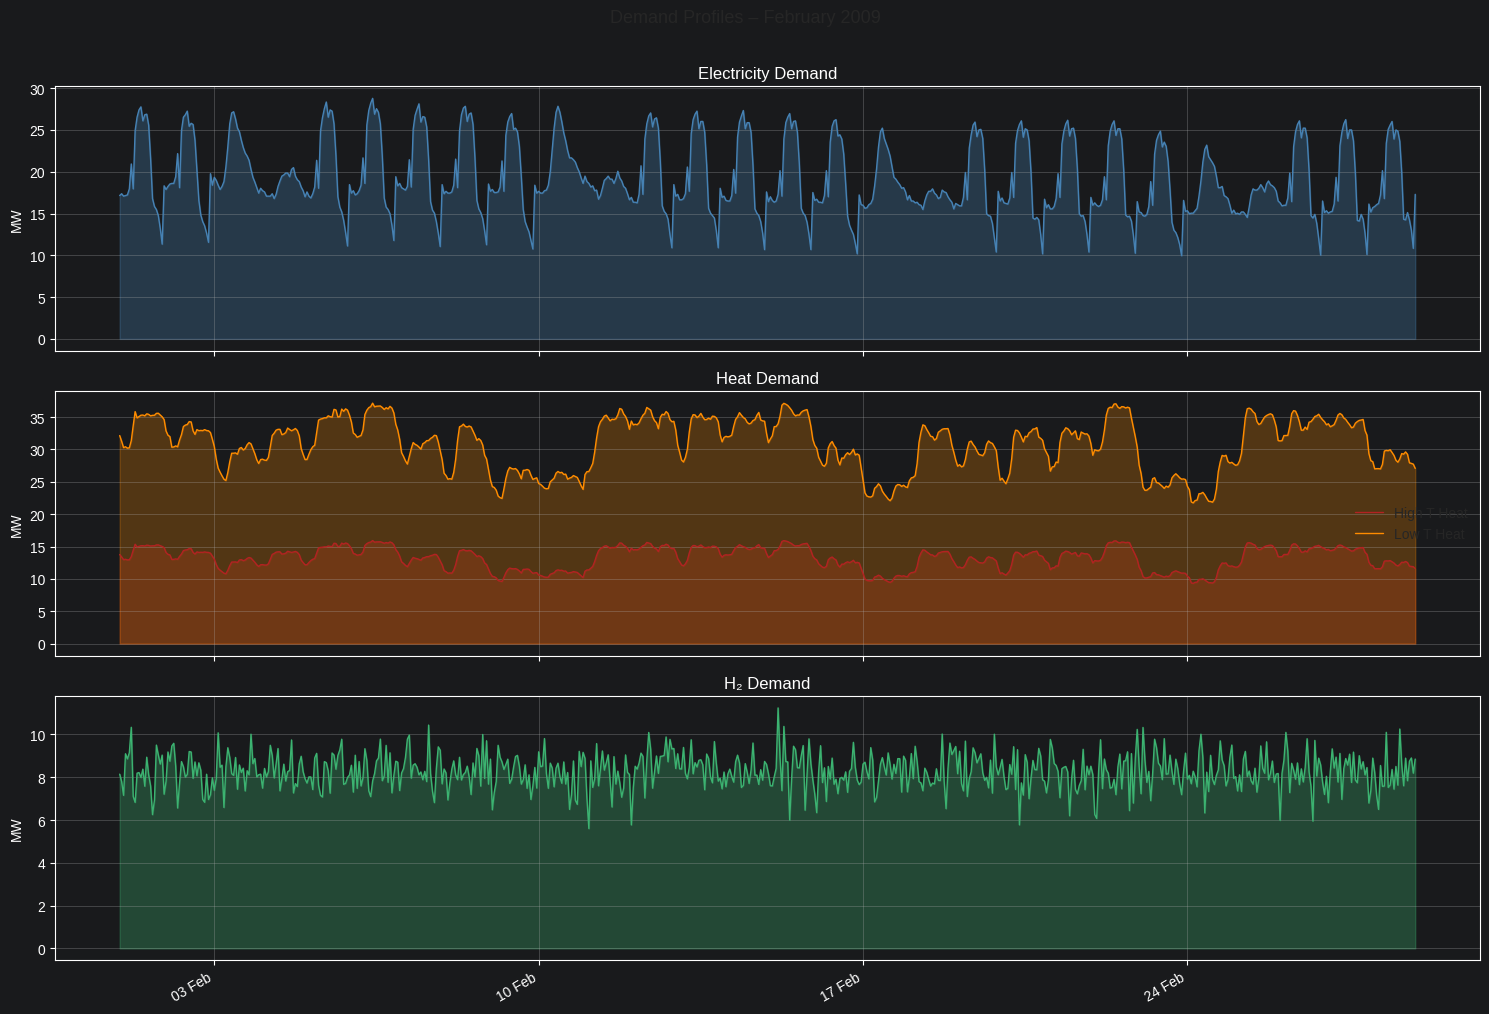

In [108]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
plt.style.use("seaborn-v0_8-whitegrid")

# Electricity demand
axes[0].plot(times, el_demand2.values, color='steelblue', linewidth=1)
axes[0].fill_between(times, el_demand2.values, alpha=0.3, color='steelblue')
axes[0].set_ylabel('MW')
axes[0].set_title('Electricity Demand')
axes[0].grid(True, alpha=0.4)

# Heat demand (High T + Low T together)
axes[1].plot(times, H_heat_demand2.values, label='High T Heat', color='firebrick', linewidth=1)
axes[1].fill_between(times, H_heat_demand2.values, alpha=0.25, color='firebrick')
axes[1].plot(times, L_heat_demand2.values, label='Low T Heat', color='darkorange', linewidth=1)
axes[1].fill_between(times, L_heat_demand2.values, alpha=0.25, color='darkorange')
axes[1].set_ylabel('MW')
axes[1].set_title('Heat Demand')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

#Hydrogen demand
axes[2].plot(times, hydrogen_demand2.values, color='mediumseagreen', linewidth=1)
axes[2].fill_between(times, hydrogen_demand2.values, alpha=0.3, color='mediumseagreen')
axes[2].set_ylabel('MW')
axes[2].set_title('H₂ Demand')
axes[2].grid(True, alpha=0.4)

# Shared x-axis formatting
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[2].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
fig.autofmt_xdate(rotation=30)

plt.suptitle('Demand Profiles – February 2009', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [109]:
n.loads_t.p_set.describe()

name,electricity_demand,heat_low_demand,heat_high_demand,hydrogen_demand
count,672.000000,672.000000,672.000000,672.000000
mean,19.154613,30.871536,13.230658,8.277241
std,4.430892,3.984314,1.707563,0.823964
min,9.957652,21.749628,9.321269,5.598701
25%,16.063072,27.852214,11.936663,7.749594
50%,17.989188,31.570381,13.530163,8.258627
75%,23.222406,34.330614,14.713120,8.808136
max,28.782701,37.163085,15.927037,11.237775


Production Capability

Our electricity capacity factors were the same as in Part 1

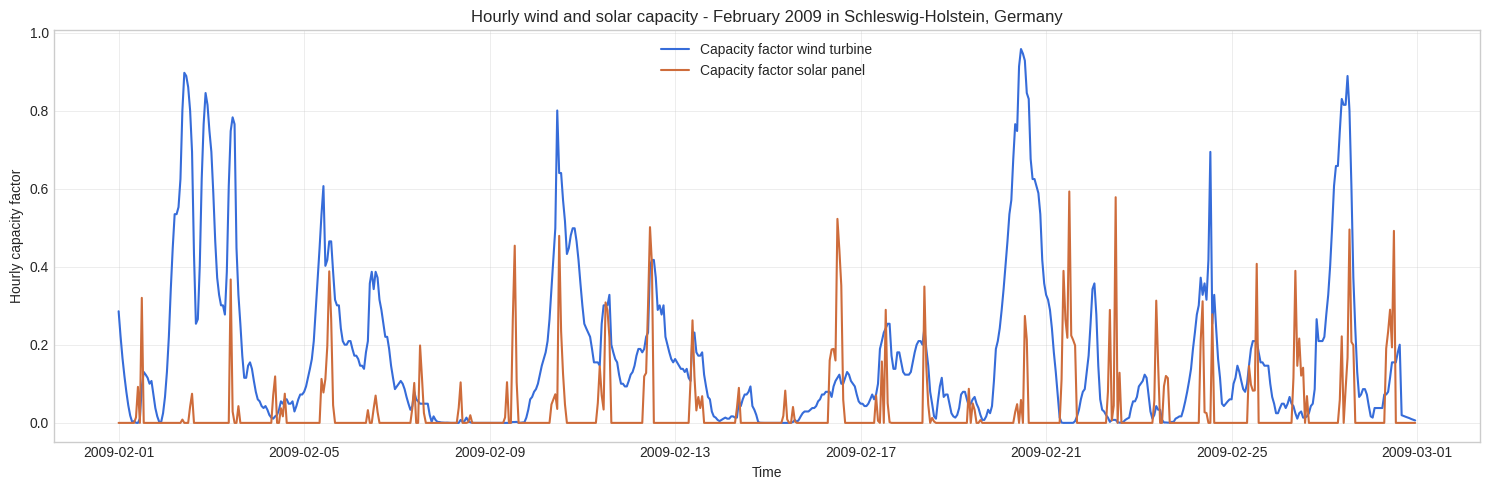

In [110]:
# Plot of capacity factors

plt.figure(figsize=(15, 5))

plt.plot(capacity_factor_wind.index, capacity_factor_wind, label='Capacity factor wind turbine')
plt.plot(capacity_factor_solar.index, capacity_factor_solar, label='Capacity factor solar panel')

plt.xlabel('Time')
plt.ylabel('Hourly capacity factor')
plt.title('Hourly wind and solar capacity - February 2009 in Schleswig-Holstein, Germany')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

We now also have hourly H2 production data given to us.

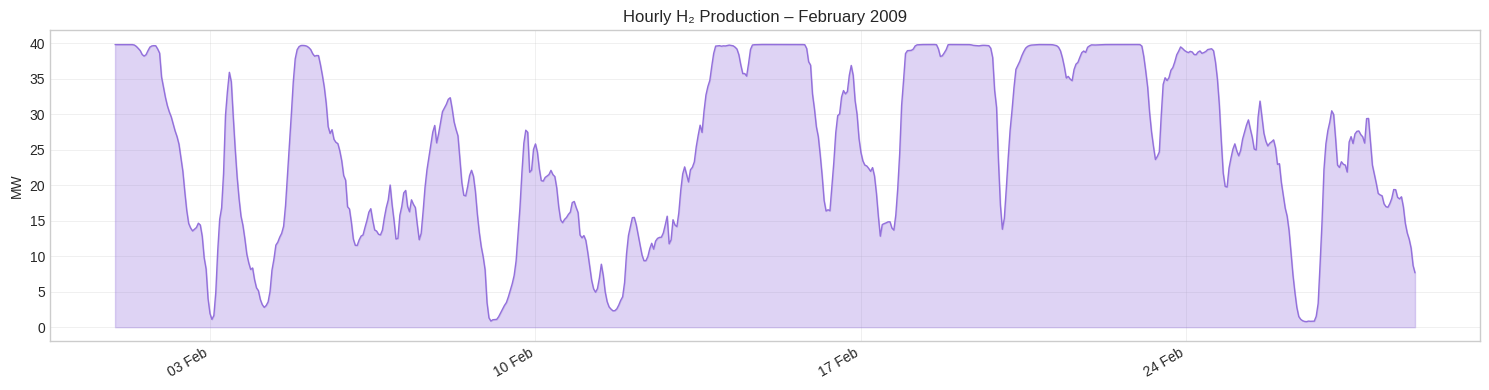

count    672.000000
mean      25.622945
std       12.200231
min        0.784013
25%       15.452480
50%       26.075798
75%       38.911493
max       39.849300
Name: H2 Production [MWh], dtype: float64

In [111]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(15, 4))

ax.plot(times, H2_available.values, color='mediumpurple', linewidth=1)
ax.fill_between(times, H2_available.values, alpha=0.3, color='mediumpurple')

ax.set_ylabel('MW')
ax.set_title('Hourly H₂ Production – February 2009')
ax.grid(True, alpha=0.4)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
fig.autofmt_xdate(rotation=30)

plt.tight_layout()
plt.show()

H2_available.describe()

### Scenario Goals
In our models we ran a number of scenarios to investigate the relationship between design parameters and numerous KPIs. The parameter configurations of each scenario can be found here:
https://docs.google.com/spreadsheets/d/1TDLvnTkoasLHzYvYxa_W-6mtMj7YGGRmXB0ouGcNCcE/edit?gid=0#gid=0

### KPI Overview
Scenarios were analyzed for impact across the following KPIs:
- RES curtailment
- unserved demand across energy types
- conversion and transport losses (for non electric)
- total additional cost, transmission utilization for L12
- number of hours that L32 is at max capacity
- number of hours H2 reservoir is empty or full (binding storage constraints).

Figures and narrative addressing each KPI are detailed in the sections below.

In [112]:
def build_cost_df(n, annualized_capex_wind, annualized_opex_wind,
                      annualized_capex_solar, annualized_opex_solar,
                      annualized_capex_battery, annualized_opex_battery,
                      annualized_capex_transmission, annualized_opex_transmission,
                      annualized_capex_pipeline, annualized_opex_pipeline,
                      annualized_capex_hydrogen_storage, annualized_opex_hydrogen_storage,
                      annualized_capex_heat_high_storage, annualized_opex_heat_high_storage,
                      annualized_capex_heat_low_storage, annualized_opex_heat_low_storage,
                      Operational_cost_electricity_import_cost,
                      Operational_cost_lost_load_penalty):

    opt_wind       = n.generators.p_nom_opt.get("wind_zone1", 0)
    opt_solar      = n.generators.p_nom_opt.get("solar_zone1", 0)
    opt_h2_zone3   = n.generators.p_nom_opt.get("h2_zone3", 0)
    opt_battery_z1 = n.storage_units.p_nom_opt.get("battery storage zone 1", 0)
    opt_battery_z2 = n.storage_units.p_nom_opt.get("battery storage zone 2", 0)
    opt_import_mwh    = n.generators_t.p.get("import", pd.Series(dtype=float)).sum()
    opt_loadshed_mwh  = n.generators_t.p.get("load shedding", pd.Series(dtype=float)).sum()
    opt_loadshed_h2 = n.generators_t.p.get("loadshed_hydrogen", pd.Series(dtype=float)).sum()
    opt_loadshed_heat_h = n.generators_t.p.get("loadshed_heat_high", pd.Series(dtype=float)).sum()
    opt_loadshed_heat_l = n.generators_t.p.get("loadshed_heat_low", pd.Series(dtype=float)).sum()


    transmission_cap = n.links.p_nom_opt.get("zone1-zone2", n.links.p_nom.get("zone1-zone2", 0))
    pipeline_cap     = n.links.p_nom_opt.get("zone3-zone2", n.links.p_nom.get("zone3-zone2", 0))

    h2_store_cap    = n.stores.e_nom_opt.get("h2_storage_zone3", 0)
    ht_store_cap    = n.stores.e_nom_opt.get("heat_high_storage", 0)
    lt_store_cap    = n.stores.e_nom_opt.get("heat_low_storage",  0)

    monthly_annualizer = len(times) / 8760

    cost_data = {
        "wind":            {"CAPEX": annualized_capex_wind * opt_wind * monthly_annualizer,
                            "OPEX":  annualized_opex_wind  * opt_wind * monthly_annualizer},
        "solar":           {"CAPEX": annualized_capex_solar * opt_solar * monthly_annualizer,
                            "OPEX":  annualized_opex_solar  * opt_solar * monthly_annualizer},
        "battery z1":      {"CAPEX": annualized_capex_battery * opt_battery_z1 * monthly_annualizer,
                            "OPEX":  annualized_opex_battery  * opt_battery_z1 * monthly_annualizer},
        "battery z2":      {"CAPEX": annualized_capex_battery * opt_battery_z2 * monthly_annualizer,
                            "OPEX":  annualized_opex_battery  * opt_battery_z2 * monthly_annualizer},
        "transmission":    {"CAPEX": annualized_capex_transmission * transmission_cap * monthly_annualizer,
                            "OPEX":  annualized_opex_transmission  * transmission_cap * monthly_annualizer},
        "H2 pipeline":     {"CAPEX": annualized_capex_pipeline * pipeline_cap * monthly_annualizer,
                            "OPEX":  annualized_opex_pipeline  * pipeline_cap * monthly_annualizer},
        "H2 storage":      {"CAPEX": annualized_capex_hydrogen_storage * h2_store_cap * monthly_annualizer,
                            "OPEX":  annualized_opex_hydrogen_storage  * h2_store_cap * monthly_annualizer},
        "heat HT storage": {"CAPEX": annualized_capex_heat_high_storage * ht_store_cap * monthly_annualizer,
                            "OPEX":  annualized_opex_heat_high_storage  * ht_store_cap * monthly_annualizer},
        "heat LT storage": {"CAPEX": annualized_capex_heat_low_storage * lt_store_cap * monthly_annualizer,
                            "OPEX":  annualized_opex_heat_low_storage  * lt_store_cap * monthly_annualizer},
        "import":          {"CAPEX": 0,
                            "OPEX":  Operational_cost_electricity_import_cost * opt_import_mwh},
        "load shed":       {"CAPEX": 0,
                            "OPEX":  Operational_cost_lost_load_penalty * opt_loadshed_mwh},
        "load shed h2":  {"CAPEX": 0,
                            "OPEX":  Operational_cost_lost_load_penalty * opt_loadshed_h2},
        "load shed heat high":       {"CAPEX": 0,
                            "OPEX":  Operational_cost_lost_load_penalty * opt_loadshed_heat_h},
        "load shed heat low":       {"CAPEX": 0,
                            "OPEX":  Operational_cost_lost_load_penalty * opt_loadshed_heat_l},
    }
    return pd.DataFrame(cost_data).T.div(1e6)  # M€


# ── Cost parameters (shared across scenarios) ─────────────────────────────────
cost_params = dict(
    annualized_capex_wind=annualized_capex_wind,
    annualized_opex_wind=annualized_opex_wind,
    annualized_capex_solar=annualized_capex_solar,
    annualized_opex_solar=annualized_opex_solar,
    annualized_capex_battery=annualized_capex_battery,
    annualized_opex_battery=annualized_opex_battery,
    annualized_capex_transmission=annualized_capex_transmission,
    annualized_opex_transmission=annualized_opex_transmission,
    annualized_capex_pipeline=annualized_capex_pipeline,
    annualized_opex_pipeline=annualized_opex_pipeline,
    annualized_capex_hydrogen_storage=annualized_capex_hydrogen_storage,
    annualized_opex_hydrogen_storage=annualized_opex_hydrogen_storage,
    annualized_capex_heat_high_storage=annualized_capex_heat_high_storage,
    annualized_opex_heat_high_storage=annualized_opex_heat_high_storage,
    annualized_capex_heat_low_storage=annualized_capex_heat_low_storage,
    annualized_opex_heat_low_storage=annualized_opex_heat_low_storage,
    Operational_cost_electricity_import_cost=Operational_cost_electricity_import_cost,
    Operational_cost_lost_load_penalty=Operational_cost_lost_load_penalty,
)

In [113]:
# Run / load each scenario
# PyPSA scenario runs were saved as netCDF
networks = {
    "Full Optimization": pypsa.Network("results/scenario_2F.nc"),
    "Scenario 2A": pypsa.Network("results/scenario_2A.nc"),
    # "Scenario 2B": pypsa.Network("results/scenario_2B.nc"),
    # "Scenario 2C": pypsa.Network("results/scenario_2C.nc"),
    # "Scenario 2D": pypsa.Network("results/scenario_2D.nc"),
}
for label, n in networks.items():
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    display(n.statistics())

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, stores, sub_networks



  Full Optimization


Optimal Capacity  Installed Capacity  \
Generator   hydrogen                      39.84930             39.8493   
            imported electricity          25.00000             25.0000   
            load shedding                 93.11060             93.1106   
            wind                         142.32717              0.0000   
Link        electricity                   64.94860              0.0000   
            h2 boiler                     33.45854              0.0000   
            heat pump                     38.83511              0.0000   
            heat_high_storage             24.87013              0.0000   
            heat_low_storage             135.44712              0.0000   
            hydrogen pipeline             39.81293              0.0000   
            hydrogen storage             100.00000            100.0000   
Load        electricity                    0.00000              0.0000   
            heat_high_temp                 0.00000              0.0000   
            heat_low_temp                  0.00000              0.0000   
            hydrogen                       0.00000              0.0000   
StorageUnit battery                        4.42922             10.0000   
Store       heat_high_storage           1029.00812              0.0000   
            heat_low_storage            3190.95178              0.0000   
            hydrogen storage             100.00000              0.0000   

                                       Supply   Withdrawal  Energy Balance  \
Generator   hydrogen              17218.61879      0.00000     17218.61879   
            imported electricity   5325.37260      0.00000      5325.37260   
            load shedding          1637.49023      0.00000      1637.49023   
            wind                  13857.37419      0.00000     13857.37419   
Link        electricity               0.00000  13868.09904    -13868.09904   
            h2 boiler                 0.00000  11455.91477    -11455.91477   
            heat pump                 0.00000   5950.25384     -5950.25384   
            heat_high_storage         0.00000   2821.40813     -2821.40813   
            heat_low_storage          0.00000  24450.09650    -24450.09650   
            hydrogen pipeline         0.00000  17171.12830    -17171.12830   
            hydrogen storage          0.00000    671.58750      -671.58750   
Load        electricity               0.00000  12871.89984    -12871.89984   
            heat_high_temp            0.00000   8891.00246     -8891.00246   
            heat_low_temp             0.00000  20745.67241    -20745.67241   
            hydrogen                  0.00000   5562.30612     -5562.30612   
StorageUnit battery                 183.18562    172.46077        10.72485   
Store       heat_high_storage      1321.20089   1485.20517      -164.00428   
            heat_low_storage      12184.94024  12265.15626       -80.21602   
            hydrogen storage        312.04850    316.39432        -4.34581   

                                  Transmission  Capacity Factor  Curtailment  \
Generator   hydrogen                   0.00000         0.642996      0.00000   
            imported electricity       0.00000         0.316986  11474.62740   
            load shedding              0.00000         0.026170  60932.83145   
            wind                       0.00000         0.144885   2305.58011   
Link        electricity            13868.09904         0.317744      0.00000   
            h2 boiler                  0.00000         0.509511      0.00000   
            heat pump                  0.00000         0.228003      0.00000   
            heat_high_storage       2821.40813         0.168818      0.00000   
            heat_low_storage       24450.09650         0.268622      0.00000   
            hydrogen pipeline      17171.12830         0.641808      0.00000   
            hydrogen storage         671.58750         0.009994      0.00000   
Load        electricity         


  Scenario 2A


Optimal Capacity  Installed Capacity  \
Generator   hydrogen                      39.84930             39.8493   
            imported electricity          25.00000             25.0000   
            load shedding                 93.11060             93.1106   
            wind                         142.32717              0.0000   
Link        electricity                   64.94860              0.0000   
            h2 boiler                     33.48524              0.0000   
            heat pump                     38.83511              0.0000   
            heat_high_storage             24.87013              0.0000   
            heat_low_storage             135.44712              0.0000   
            hydrogen pipeline            100.00000              0.0000   
            hydrogen storage             100.00000            100.0000   
Load        electricity                    0.00000              0.0000   
            heat_high_temp                 0.00000              0.0000   
            heat_low_temp                  0.00000              0.0000   
            hydrogen                       0.00000              0.0000   
StorageUnit battery                        4.42922             10.0000   
Store       heat_high_storage           1029.06748              0.0000   
            heat_low_storage            3190.95178              0.0000   
            hydrogen storage             100.00000              0.0000   

                                       Supply   Withdrawal  Energy Balance  \
Generator   hydrogen              17218.61879      0.00000     17218.61879   
            imported electricity   5325.37260      0.00000      5325.37260   
            load shedding          1637.43953      0.00000      1637.43953   
            wind                  13857.37419      0.00000     13857.37419   
Link        electricity               0.00000  13868.09904    -13868.09904   
            h2 boiler                 0.00000  11456.07698    -11456.07698   
            heat pump                 0.00000   5950.25384     -5950.25384   
            heat_high_storage         0.00000   2821.56478     -2821.56478   
            heat_low_storage          0.00000  24450.09650    -24450.09650   
            hydrogen pipeline         0.00000  17171.29197    -17171.29197   
            hydrogen storage          0.00000    669.12280      -669.12280   
Load        electricity               0.00000  12871.89984    -12871.89984   
            heat_high_temp            0.00000   8891.00246     -8891.00246   
            heat_low_temp             0.00000  20745.67241    -20745.67241   
            hydrogen                  0.00000   5562.30612     -5562.30612   
StorageUnit battery                 183.18562    172.46077        10.72485   
Store       heat_high_storage      1321.25210   1485.30955      -164.05745   
            heat_low_storage      12184.94024  12265.15626       -80.21602   
            hydrogen storage        310.89799    315.23783        -4.33985   

                                  Transmission  Capacity Factor  Curtailment  \
Generator   hydrogen                   0.00000         0.642996      0.00000   
            imported electricity       0.00000         0.316986  11474.62740   
            load shedding              0.00000         0.026170  60932.88216   
            wind                       0.00000         0.144885   2305.58011   
Link        electricity            13868.09904         0.317744      0.00000   
            h2 boiler                  0.00000         0.509112      0.00000   
            heat pump                  0.00000         0.228003      0.00000   
            heat_high_storage       2821.56478         0.168827      0.00000   
            heat_low_storage       24450.09650         0.268622      0.00000   
            hydrogen pipeline      17171.29197         0.255525      0.00000   
            hydrogen storage         669.12280         0.009957      0.00000   
Load        electricity         

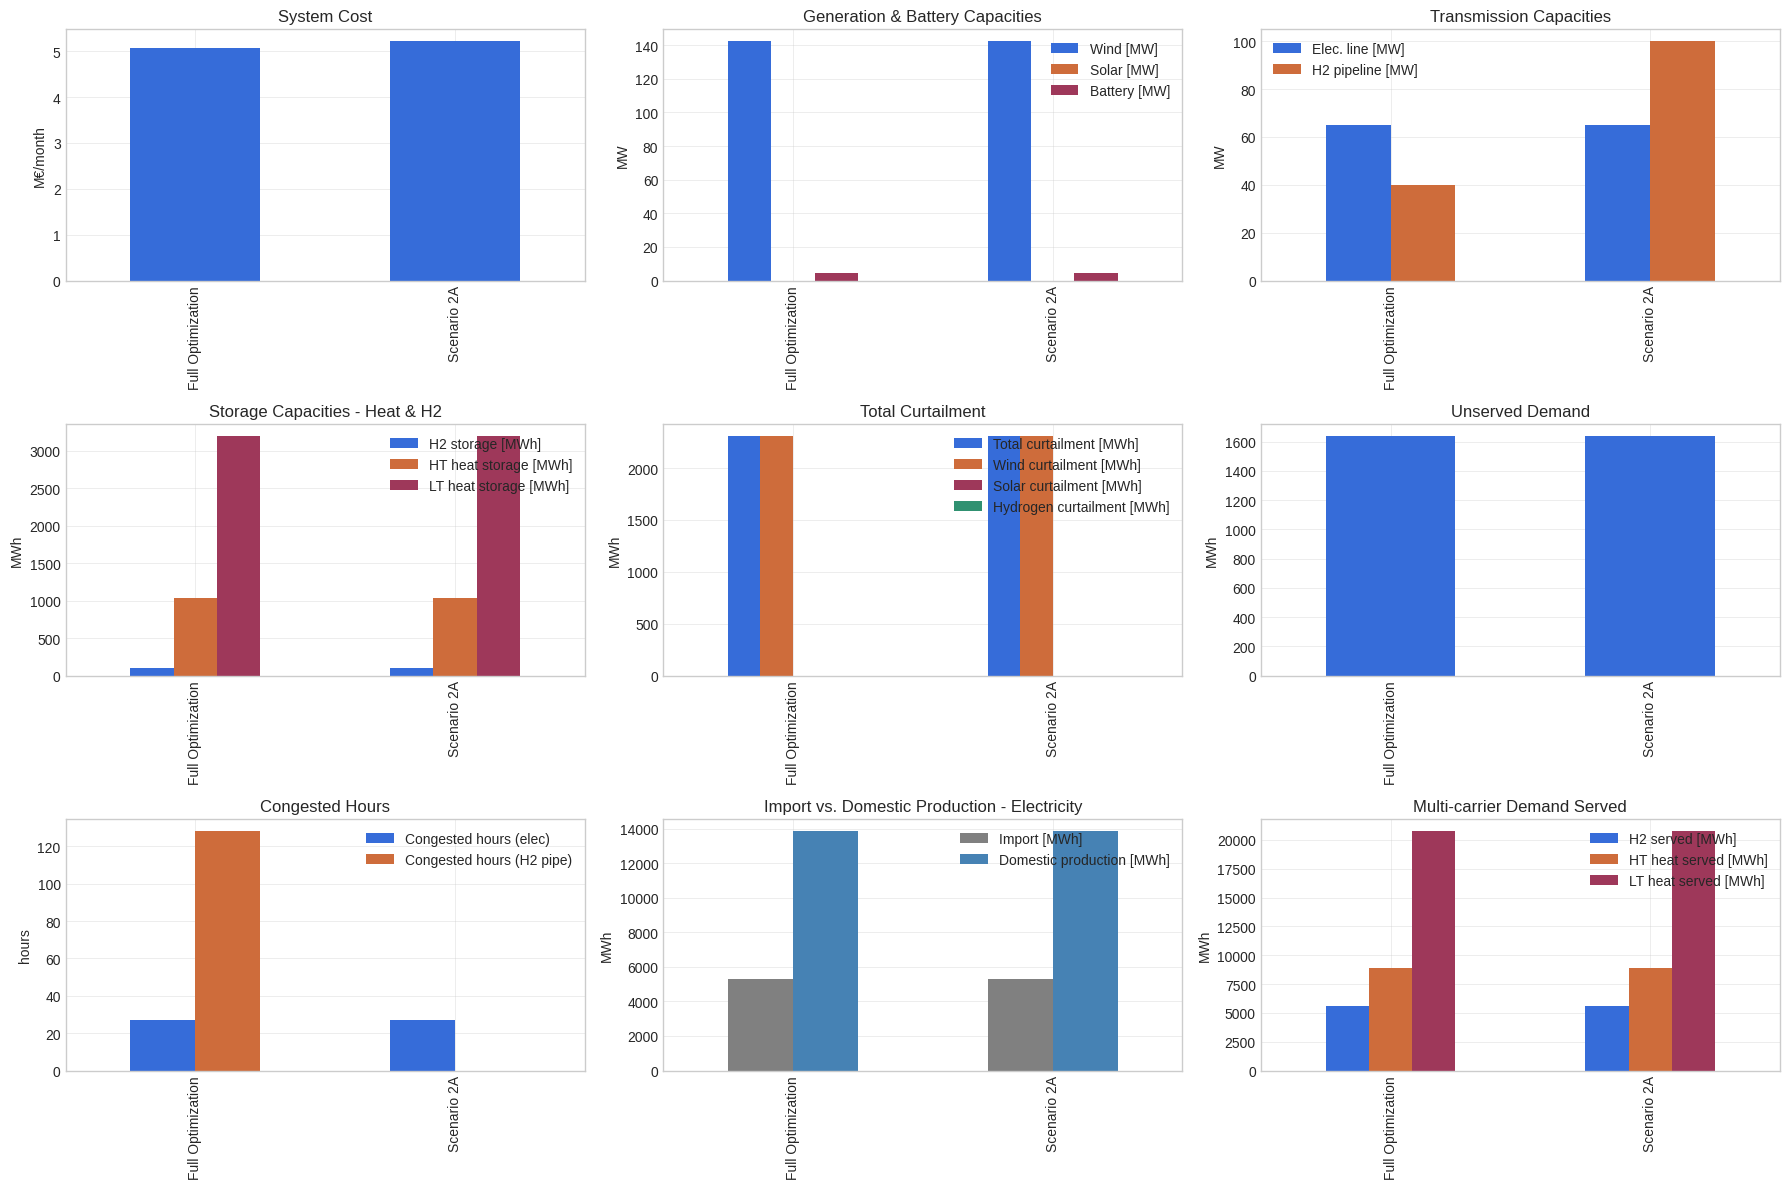

,Total cost [M€/m],Wind [MW],Solar [MW],Battery [MW],Elec. line [MW],H2 pipeline [MW],H2 storage [MWh],HT heat storage [MWh],LT heat storage [MWh],Wind curtailment [MWh],Solar curtailment [MWh],Hydrogen curtailment [MWh],Total curtailment [MWh],Congested hours (elec),Congested hours (H2 pipe),Import [MWh],Domestic production [MWh],Domestic share [%],H2 served [MWh],HT heat served [MWh],LT heat served [MWh],Unserved elec [MWh],Unserved H2 [MWh],Unserved HT heat [MWh],Unserved LT heat [MWh],Total unserved [MWh]
Full Optimization,5.07,142.33,-0.00,4.43,64.95,39.81,100.00,1029.01,3190.95,2305.58,0.00,0.00,2305.58,27.00,128.00,5325.37,13857.37,0.29,5562.31,8891.00,20745.67,0.61,0.00,1636.88,0.00,1637.49
Scenario 2A,5.21,142.33,-0.00,4.43,64.95,100.00,100.00,1029.07,3190.95,2305.58,0.00,0.00,2305.58,27.00,0.00,5325.37,13857.37,0.29,5562.31,8891.00,20745.67,0.61,0.00,1636.83,0.00,1637.44


In [114]:

# Extract KPIs from each network
def extract_kpis(n, label):

#Capacities
    opt_wind       = n.generators.p_nom_opt.get("wind_zone1", 0)
    opt_solar      = n.generators.p_nom_opt.get("solar_zone1", 0)
    opt_hydrogen   = n.generators.p_nom_opt.get("h2_zone3", 0)
    opt_batt       = n.storage_units.p_nom_opt.sum()
    opt_line       = n.links.p_nom_opt.get("zone1-zone2", n.links.p_nom.get("zone1-zone2", 0))
    opt_pipeline   = n.links.p_nom_opt.get("zone3-zone2", n.links.p_nom.get("zone3-zone2", 0))
    opt_h2_store   = n.stores.e_nom_opt.get("h2_storage_zone3", 0)
    opt_ht_store   = n.stores.e_nom_opt.get("heat_high_storage", 0)
    opt_lt_store   = n.stores.e_nom_opt.get("heat_low_storage",  0)

# Loads
    import_mwh    = n.generators_t.p.get("import",        pd.Series(0, dtype=float)).sum()
    unserved_mwh = sum(
        n.generators_t.p.get(name, pd.Series(0, dtype=float)).sum()
        for name in ["load shedding", "loadshed_hydrogen", "loadshed_heat_high", "loadshed_heat_low"]
)

    #  Curtailment
    opt_wind_mw   = n.generators.p_nom_opt["wind_zone1"]  * n.generators_t.p_max_pu["wind_zone1"]
    opt_solar_mw  = n.generators.p_nom_opt["solar_zone1"] * n.generators_t.p_max_pu["solar_zone1"]
    opt_hydrogen_mw = n.generators.p_nom_opt["h2_zone3"] * n.generators_t.p_max_pu["h2_zone3"]

    gen_wind      = n.generators_t.p["wind_zone1"]
    gen_solar     = n.generators_t.p["solar_zone1"]
    gen_hydrogen  = n.generators_t.p["h2_zone3"]
    curtailment_wind  = (opt_wind_mw  - gen_wind ).clip(lower=0).sum()
    curtailment_solar = (opt_solar_mw - gen_solar).clip(lower=0).sum()
    curtailment_hydrogen = (opt_hydrogen_mw - gen_hydrogen).clip(lower=0).sum()
    total_curtailment = curtailment_wind + curtailment_solar + curtailment_hydrogen

    # Energy security
    domestic_production = (gen_wind + gen_solar).sum()
    total_load          = n.loads_t.p.sum().sum()
    domestic_share      = domestic_production / total_load if total_load > 0 else 0

    # H2 & heat served ─────────────────────────────
    h2_served = n.loads_t.p["hydrogen_demand"].sum()
    ht_served  = n.loads_t.p["heat_high_demand"].sum()
    lt_served  = n.loads_t.p["heat_low_demand"].sum()

    # ── Congestion (electricity line) ─────────────────
    if "zone1-zone2" in n.links_t.p0.columns:
        cap = n.links.p_nom_opt.get("zone1-zone2", n.links.p_nom.get("zone1-zone2", 0))
        congested_hours = int((n.links_t.p0["zone1-zone2"].abs() / cap > 0.99).sum()) if cap > 0 else 0
    else:
        congested_hours = 0

    # ── Congestion (H2 pipeline) ──────────────────────
    if "zone3-zone2" in n.links_t.p0.columns:
        cap_pipe = n.links.p_nom_opt.get("zone3-zone2", n.links.p_nom.get("zone3-zone2", 0))
        congested_hours_pipe = int((n.links_t.p0["zone3-zone2"].abs() / cap_pipe > 0.99).sum()) if cap_pipe > 0 else 0
    else:
        congested_hours_pipe = 0

    # ── Cost ──────────────────────────────────────────
    cost_df    = build_cost_df(n, **cost_params)
    total_cost = cost_df["CAPEX"].sum() + cost_df["OPEX"].sum()

    return {
        "Total cost [M€/m]":          total_cost,
        "Wind [MW]":                   opt_wind,
        "Solar [MW]":                  opt_solar,
        "Battery [MW]":                opt_batt,
        "Elec. line [MW]":             opt_line,
        "H2 pipeline [MW]":            opt_pipeline,
        "H2 storage [MWh]":            opt_h2_store,
        "HT heat storage [MWh]":       opt_ht_store,
        "LT heat storage [MWh]":       opt_lt_store,
        "Wind curtailment [MWh]":      curtailment_wind,
        "Solar curtailment [MWh]":     curtailment_solar,
        "Hydrogen curtailment [MWh]": curtailment_hydrogen,
        "Total curtailment [MWh]":     total_curtailment,
        "Congested hours (elec)":      congested_hours,
        "Congested hours (H2 pipe)":   congested_hours_pipe,
        "Import [MWh]":                import_mwh,
        "Domestic production [MWh]":   domestic_production,
        "Domestic share [%]":          domestic_share,
        "H2 served [MWh]":             h2_served,
        "HT heat served [MWh]":        ht_served,
        "LT heat served [MWh]":        lt_served,
        "Unserved elec [MWh]":   n.generators_t.p.get("load shedding",      pd.Series(0, dtype=float)).sum(),
        "Unserved H2 [MWh]":     n.generators_t.p.get("loadshed_hydrogen",   pd.Series(0, dtype=float)).sum(),
        "Unserved HT heat [MWh]":n.generators_t.p.get("loadshed_heat_high",  pd.Series(0, dtype=float)).sum(),
        "Unserved LT heat [MWh]":n.generators_t.p.get("loadshed_heat_low",   pd.Series(0, dtype=float)).sum(),
        "Total unserved [MWh]":  unserved_mwh,
    }

kpis = pd.DataFrame(
    {label: extract_kpis(n, label) for label, n in networks.items()}
)

# ── 3. Side-by-side bar charts ────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

kpis.loc[["Total cost [M€/m]"]].T.plot(kind="bar", ax=axes[0], legend=False)
axes[0].set_title("System Cost"); axes[0].set_ylabel("M€/month")

kpis.loc[["Wind [MW]", "Solar [MW]", "Battery [MW]"]].T.plot(kind="bar", ax=axes[1])
axes[1].set_title("Generation & Battery Capacities"); axes[1].set_ylabel("MW")

kpis.loc[["Elec. line [MW]", "H2 pipeline [MW]"]].T.plot(kind="bar", ax=axes[2])
axes[2].set_title("Transmission Capacities"); axes[2].set_ylabel("MW")

kpis.loc[["H2 storage [MWh]", "HT heat storage [MWh]", "LT heat storage [MWh]"]].T.plot(kind="bar", ax=axes[3])
axes[3].set_title("Storage Capacities - Heat & H2"); axes[3].set_ylabel("MWh")

kpis.loc[["Total curtailment [MWh]","Wind curtailment [MWh]","Solar curtailment [MWh]","Hydrogen curtailment [MWh]"  ]].T.plot(kind="bar", ax=axes[4])
axes[4].set_title("Total Curtailment"); axes[4].set_ylabel("MWh")

kpis.loc[["Total unserved [MWh]"]].T.plot(kind="bar", ax=axes[5], legend=False)
axes[5].set_title("Unserved Demand"); axes[5].set_ylabel("MWh")

kpis.loc[["Congested hours (elec)", "Congested hours (H2 pipe)"]].T.plot(kind="bar", ax=axes[6])
axes[6].set_title("Congested Hours"); axes[6].set_ylabel("hours")

kpis.loc[["Import [MWh]", "Domestic production [MWh]"]].T.plot(kind="bar", ax=axes[7], color=["grey", "steelblue"])
axes[7].set_title("Import vs. Domestic Production - Electricity"); axes[7].set_ylabel("MWh")

kpis.loc[["H2 served [MWh]", "HT heat served [MWh]", "LT heat served [MWh]"]].T.plot(kind="bar", ax=axes[8])
axes[8].set_title("Multi-carrier Demand Served"); axes[8].set_ylabel("MWh")

plt.tight_layout(); plt.show()

display(
    kpis.T.style
        .format("{:.2f}")
        .background_gradient(cmap="RdYlGn_r", axis=0)
        .set_caption("KPI Comparison Across Scenarios")
)

The figures and tables above represent an overview of the KPIs across our scenarios.

### System Cost Comparision

In the figures below, we can see different design choices reflected in the overall system costs.

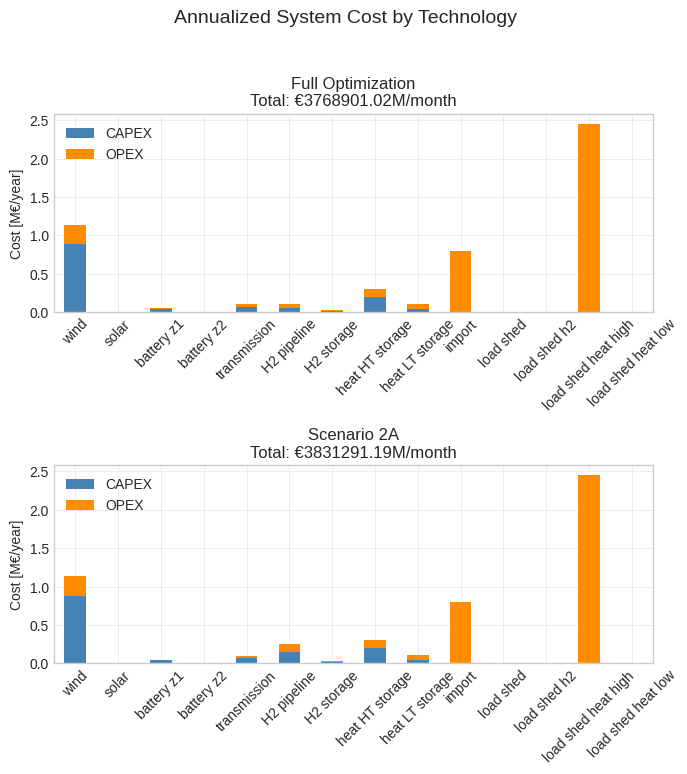

In [115]:
import math

n_plots = len(networks)
n_rows = 3
n_cols = math.ceil(n_plots / n_rows)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 10), sharey=True)

axes = axes.flatten()  # makes iteration easy

for ax, (label, n) in zip(axes, networks.items()):
    cost_df = build_cost_df(n, **cost_params)
    total   = cost_df["CAPEX"].sum() + cost_df["OPEX"].sum() * 1e6

    cost_df[["CAPEX", "OPEX"]].plot(
        kind="bar", stacked=True, ax=ax,
        color=["steelblue", "darkorange"]
    )
    ax.set_title(f"{label}\nTotal: €{total:.2f}M/month")
    ax.set_ylabel("Cost [M€/year]")
    ax.tick_params(axis="x", rotation=45)

# hide any unused subplots
for ax in axes[len(networks):]:
    ax.set_visible(False)

plt.suptitle("Annualized System Cost by Technology", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Curtailment
In our scenarios we seek to lower curtailment.

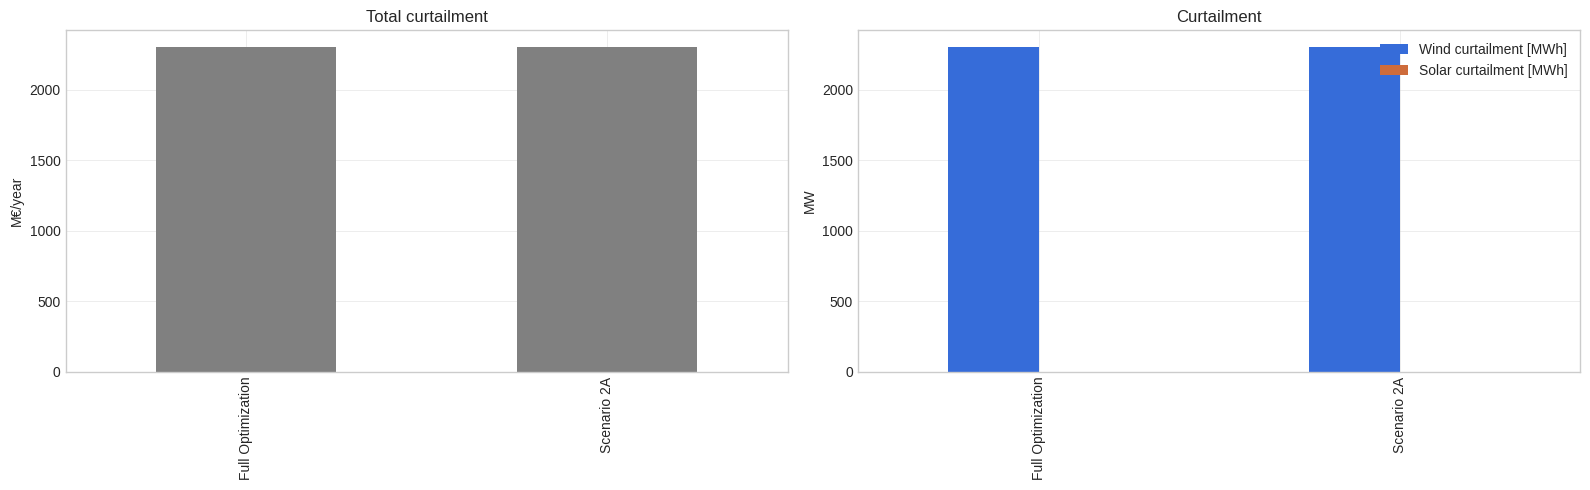

,Wind curtailment [MWh],Solar curtailment [MWh],Total curtailment [MWh]
Full Optimization,2305.6,0.0,2305.6
Scenario 2A,2305.6,0.0,2305.6


,Wind curtailment [MWh],Solar curtailment [MWh],Total curtailment [MWh]
Full Optimization,2305.6,0.0,2305.6
Scenario 2A,2305.6,0.0,2305.6


In [116]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

kpis.loc[["Total curtailment [MWh]"]].T \
    .plot(kind="bar", ax=axes[0], legend=False, color="grey")
axes[0].set_title("Total curtailment"); axes[0].set_ylabel("M€/year")

kpis.loc[["Wind curtailment [MWh]", "Solar curtailment [MWh]"]].T \
    .plot(kind="bar", ax=axes[1]); axes[1].set_title("Curtailment"); axes[1].set_ylabel("MW")

plt.tight_layout(); plt.show()

curtailment_table = kpis.loc[["Wind curtailment [MWh]", "Solar curtailment [MWh]", "Total curtailment [MWh]"]].T
display(curtailment_table.round(1))
display(
    curtailment_table.round(1).style
        .set_caption("Curtailment by Scenario")
        .format("{:.1f}")
        .background_gradient(cmap="Reds", axis=0)
)

### Transmission / Utilization of the Line
A goal of our system is to avoid line and pipeline congestion.

KeyError: "None of [Index(['Congested hours'], dtype='object')] are in the [index]"

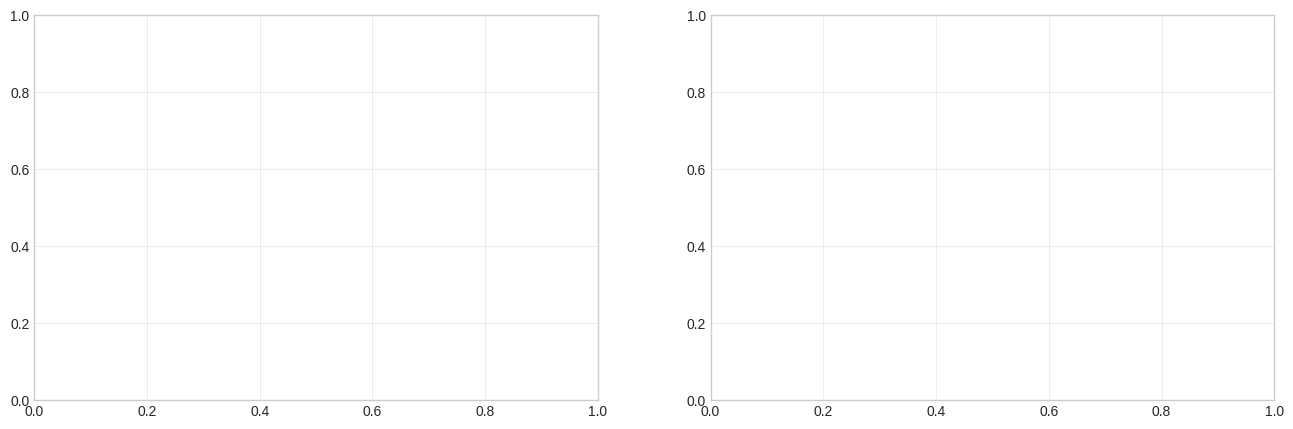

In [117]:
def plot_line_utilization_combined(networks, ax, highlight="Scenario D"):
    valid = {label: n for label, n in networks.items()
             if "zone1-zone2" in n.links_t.p0.columns}

    if not valid:
        print("No networks have link flow data.")
        return

    for label, n in valid.items():
        opt_line_capacity = n.links.p_nom_opt.get("zone1-zone2",
                            n.links.p_nom.get("zone1-zone2", 0))
        if opt_line_capacity == 0:
            continue
        utilization = n.links_t.p0["zone1-zone2"].abs() / opt_line_capacity

        if label == highlight:
            ax.plot(utilization.values, label=label, color="red", linewidth=1.5, zorder=5)
        else:
            ax.plot(utilization.values, label=label, color="grey", linewidth=0.8, alpha=0.7)

    ax.set_ylabel("Utilization [% of capacity]")
    ax.set_title("Transmission Line Utilization — All Scenarios")
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

kpis.loc[["Congested hours"]].T \
    .plot(kind="bar", ax=axes[0], legend=False)
axes[0].set_title("Congested Hours")
axes[0].set_ylabel("hours")

plot_line_utilization_combined(networks, ax=axes[1], highlight="Scenario B")

plt.tight_layout()
plt.show()

A note on battery location: Originally, it was thought that a battery at Zone 2 could take advantage of "free" transmission, transmitting surplus energy to the battery at a time when cable losses were irrelevant due to the wind and solar surplus. While this may be true, this assumption's relative value was incorrect and Zone 1 was the superior location because it avoided line congestion. The battery was able to capture surplus renewables while freeing up transmission for use and only building the line infrastructure required to remain nearly matched with the max demand value (28 MW). The optimizer was not allowed to build less, as this always resulted in over importing (in violation of our Energy Security KPI which we'll discuss below).

In the figure below, Scenario B is highlighted - the only scenario to have the max capacity value of 20MW and be located at Zone 2.

In [ ]:
def get_battery_series(net, attr):
    """Return the battery time series for whichever zone exists, or None."""
    su_t = getattr(net.storage_units_t, attr)
    for name in ["battery storage zone 1", "battery storage zone 2"]:
        if name in su_t.columns:
            return su_t[name], name
    return None, None

# find scenario with largest battery across either zone
def get_max_battery_capacity(net):
    for name in ["battery storage zone 1", "battery storage zone 2"]:
        if name in net.storage_units.p_nom_opt.index:
            return net.storage_units.p_nom_opt[name]
    return 0

max_label = max(networks, key=lambda label: get_max_battery_capacity(networks[label]))

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

for label, net in networks.items():
    p_series, batt_name = get_battery_series(net, "p")
    soc_series, _       = get_battery_series(net, "state_of_charge")

    if p_series is None:
        continue

    is_max    = label == max_label
    color_p   = "steelblue" if is_max else "grey"
    color_soc = "green"     if is_max else "grey"
    lw        = 2.0 if is_max else 0.8
    alpha     = 1.0 if is_max else 0.5
    lbl       = f"{label} ({batt_name}) ★" if is_max else f"{label} ({batt_name})"

    p_series.plot(ax=axes[0], label=lbl, color=color_p, linewidth=lw, alpha=alpha)
    soc_series.plot(ax=axes[1], label=lbl, color=color_soc, linewidth=lw, alpha=alpha)

axes[0].set_ylabel("MW")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_title("Charge / Discharge Power [MW]")
axes[0].legend(fontsize=8)
axes[0].grid(True)

axes[1].set_ylabel("MWh")
axes[1].set_title("State of Charge [MWh]")
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.suptitle("Battery Operation Over Time — All Scenarios")
plt.tight_layout()
plt.show()

### Unserved Demand

Unserved demand was relegated to a non-factor after Scenario A. This was considered a priority KPI and it was important in our scenarios to limit or eliminate load shedding entirely. While 1500 EUR/MWh is much higher than the cost per MWh of RES after they are built, this penalty was not originally high enough to discourage it entirely in the Full Optimization Scenario (25 MWh). However, the introduction of a battery in Scenario A and a larger battery in Scenario B lowered and then eliminated load shedding entirely. Even prior to elimination these events had minimal impact and were rare - which is ideal.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

kpis.loc[["Total unserved [MWh]"]].T.plot(
    kind="bar",
    ax=ax,
    legend=False,
    color="grey"
)

ax.set_title("Total unserved")
ax.set_ylabel("MWh")

plt.tight_layout()
plt.show()

n_f = networks["Full Optimization"]

loadshed = n_f.generators_t.p.get("load shedding", pd.Series(dtype=float))

fig, ax = plt.subplots(figsize=(15, 4))
loadshed.plot(ax=ax, color="red", label="Load shedding")
ax.set_ylabel("MW")
ax.set_title("Unmet Demand Over Time — Scenario Full Optimization")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

print(f"Total unserved demand: {loadshed.sum():.1f} MWh")
print(f"Hours with load shedding: {(loadshed > 0).sum()}")
print(f"Peak load shedding: {loadshed.max():.1f} MW")

n_b = networks["Scenario A"]

loadshed = n_b.generators_t.p.get("load shedding", pd.Series(dtype=float))

fig, ax = plt.subplots(figsize=(15, 4))
loadshed.plot(ax=ax, color="red", label="Load shedding")
ax.set_ylabel("MW")
ax.set_title("Unmet Demand Over Time — Scenario A")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

print(f"Total unserved demand: {loadshed.sum():.1f} MWh")
print(f"Hours with load shedding: {(loadshed > 0).sum()}")
print(f"Peak load shedding: {loadshed.max():.1f} MW")

### Energy Security

Finally, this KPI was one that we added. Our relatively low demand meant that the optimizer graviated toward a backbone of imported electricity. While this remained throughout all scenarios, we made it a priority to reach at least a 50/50 split between domestic production and imports. In the Full Optimization and Scenario A this did not occur, as the lack of or limited size of the battery meant renewables were too intermittent to meet demand.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

(kpis.loc[["Domestic share [%]"]] * 100).T \
    .plot(kind="bar", ax=axes[0], legend=False, color="steelblue")
axes[0].axhline(50, color="red", linewidth=1.5, linestyle="--", label="50% target")
axes[0].legend()
axes[0].set_title("Demand Covered by Domestic Production")
axes[0].set_ylabel("%")

kpis.loc[["Import [MWh]", "Domestic production [MWh]"]].T \
    .plot(kind="bar", ax=axes[1], color=["grey", "steelblue"]); axes[1].set_title("Domestic vs. Import"); axes[1].set_ylabel("MWh")

plt.tight_layout(); plt.show()

es_table = kpis.loc[["Domestic share [%]", "Import [MWh]", "Domestic production [MWh]"]].T
display(es_table.round(1))
display(
    es_table.round(1).style
        .set_caption("Energy Security by Scenario")
        .format("{:.1f}")
        .background_gradient(cmap="Reds", axis=0)
)

### Final Reflections for Part 1: Priorities & Trade-offs

This exercise shows that when going beyond cost as the only driver, there are certain relationships and trade-offs that form when designing an energy system. For our scenarios, eliminating unmet demand and protecting domestic energy security were prioritized. The result was the creation of more RES and more battery storage than might "naturally" occur via a cost-prioritizing model. We learned this has tradeoffs for line congestion and curtailment. We also learned that without penalties or scarcities to limit activities (i.e. curtailment) they will be hard to control.

The location of battery storage is important. While we initially identified a rationale for placing our battery at Zone 2 (demand side) we learned that the transmission savings did not hold as much value as avoiding line congestion by placing the battery at Zone 1 (production side) so storage could occur without competition for transmission bandwidth.

The environment in which the system lives is important. We had relatively low demand, and as a consequence always had the luxury of import to fall back on as backbone generation. Our region also possessed great wind potential and limited solar potential which guided investments.

Were we to continue modeling this or similar systems there should be some barrier to unlimited curtailment - most likely through the introduction of more information around ramping or some other real world factors that will not allow immediate 0-max generation. We could also take into account geographic restrictions. A real-world scenario would have limitations on available land for wind and solar projects. A final improvement would be to take into account sustainability. This could be done by including emissions factors generation within the system and from imports, and introduce the economic factor of carbon penalties and credits.


Our final iteration: the energy balance of PyPSA Scenario D

In [ ]:
#energy balance
n.statistics.energy_balance.plot.area(
    bus_carrier="electricity",
    linewidth=0,
    figsize=(15, 5)
)